# Design Choice Justification for Cloud Microphysics Emulator

This notebook provides data-driven, first-principles justification for each
key modeling decision in the E3SM cloud microphysics neural network emulator.
Every figure answers: *"Here is what the raw data looks like, and here is why that
property forced us to adopt design choice X."*

**Design choices covered:**
1. Multi-head architecture (vs monolithic single-output network)
2. Input sensitivity heterogeneity across tendencies
3. Active vs quiescent regime separation
4. Improvements over predecessor classifier-gated tree-of-ANNs
5. Hard-coded mass conservation constraint (qctend = -qrtend)
6. Log10 input/output transform and StandardScaler (after log)
7. Inverse hyperbolic sine (arcsinh) transform for nrtend
8. Mixture-of-Experts (MoE) routing for nrtend
9. Input filtering thresholds and Huber loss

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import seaborn as sns
from pathlib import Path
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Presentation-quality defaults
plt.rcParams.update({
    'figure.dpi': 150,
    'savefig.dpi': 300,
    'font.size': 13,
    'axes.titlesize': 15,
    'axes.labelsize': 14,
    'xtick.labelsize': 11,
    'ytick.labelsize': 11,
    'legend.fontsize': 11,
    'figure.facecolor': 'white',
    'axes.facecolor': 'white',
    'savefig.bbox': 'tight',
    'savefig.pad_inches': 0.15,
})

COLORS = {
    'qrtend': '#2166ac',
    'nctend': '#b2182b',
    'nrtend': '#4dac26',
    'qctend': '#7570b3',
    'active': '#e66101',
    'quiescent': '#5e3c99',
}

TENDENCY_LABELS = {
    'qrtend_TAU': r'$dq_r/dt$  (rain mixing ratio)',
    'nctend_TAU': r'$dN_c/dt$  (cloud droplet number)',
    'nrtend_TAU': r'$dN_r/dt$  (rain drop number)',
    'qctend_TAU': r'$dq_c/dt$  (cloud mixing ratio)',
}

INPUT_COLS = [
    'QC_TAU_in', 'QR_TAU_in', 'NC_TAU_in', 'NR_TAU_in',
    'PGAM', 'LAMC', 'LAMR', 'N0R', 'RHO_CLUBB', 'CLOUD', 'FREQR',
]
OUTPUT_COLS = ['qctend_TAU', 'nctend_TAU', 'nrtend_TAU', 'qrtend_TAU']

INPUT_LABELS = {
    'QC_TAU_in': r'$q_c$', 'QR_TAU_in': r'$q_r$',
    'NC_TAU_in': r'$N_c$', 'NR_TAU_in': r'$N_r$',
    'PGAM': r'$\mu$', 'LAMC': r'$\lambda_c$',
    'LAMR': r'$\lambda_r$', 'N0R': r'$N_{0r}$',
    'RHO_CLUBB': r'$\rho$', 'CLOUD': r'$F_c$', 'FREQR': r'$F_r$',
}
OUTPUT_LABELS_SHORT = {
    'qrtend_TAU': r'$dq_r/dt$', 'nctend_TAU': r'$dN_c/dt$',
    'nrtend_TAU': r'$dN_r/dt$', 'qctend_TAU': r'$dq_c/dt$',
}

FIG_DIR = Path('figures')
FIG_DIR.mkdir(exist_ok=True)

print("Setup complete.")

Setup complete.


In [2]:
data_path = Path('/rcfs/projects/pioneercloud/dhruv/processed_data')
all_files = sorted(data_path.glob('e3sm_mp_data_*.parquet'))
n_total_files = len(all_files)
print(f"Total parquet files available: {n_total_files}")

TARGET_ROWS = 500_000
rows_per_file = max(1, TARGET_ROWS // n_total_files)  # ~656 rows/file
print(f"Sampling ~{rows_per_file} rows from each of {n_total_files} files "
      f"(target: ~{TARGET_ROWS:,} total)")

np.random.seed(42)
load_cols = list(dict.fromkeys(INPUT_COLS + OUTPUT_COLS + ['lev']))
frames = []
for i, fp in enumerate(all_files):
    df = pd.read_parquet(fp, columns=load_cols)
    df = df[(df['lev'] >= 250) & (df['lev'] <= 1000)]
    if len(df) > rows_per_file:
        df = df.sample(n=rows_per_file, random_state=42)
    frames.append(df)
    if (i + 1) % 100 == 0 or i == n_total_files - 1:
        print(f"  [{i+1}/{n_total_files}] files loaded ...")

data = pd.concat(frames, ignore_index=True)
print(f"\nCombined dataset: {data.shape[0]:,} rows x {data.shape[1]} columns")
print(f"Memory: {data.memory_usage(deep=True).sum() / 1e6:.1f} MB")

Total parquet files available: 762
Sampling ~656 rows from each of 762 files (target: ~500,000 total)


  [100/762] files loaded ...


  [200/762] files loaded ...


  [300/762] files loaded ...


  [400/762] files loaded ...


  [500/762] files loaded ...


  [600/762] files loaded ...


  [700/762] files loaded ...


  [762/762] files loaded ...

Combined dataset: 499,872 rows x 16 columns
Memory: 34.0 MB


---
## Why Multi-Head Architecture?

**Design choice:** Use separate regression heads for each output tendency rather
than a single fully-connected output layer that maps to all 4 tendencies simultaneously.

**Data-driven argument:** The four output tendencies have fundamentally different
statistical properties -- different sign constraints, different dynamic ranges,
and different distributional shapes.  A monolithic output layer must force a single
weight matrix to accommodate all four simultaneously, whereas separate heads can
specialize.

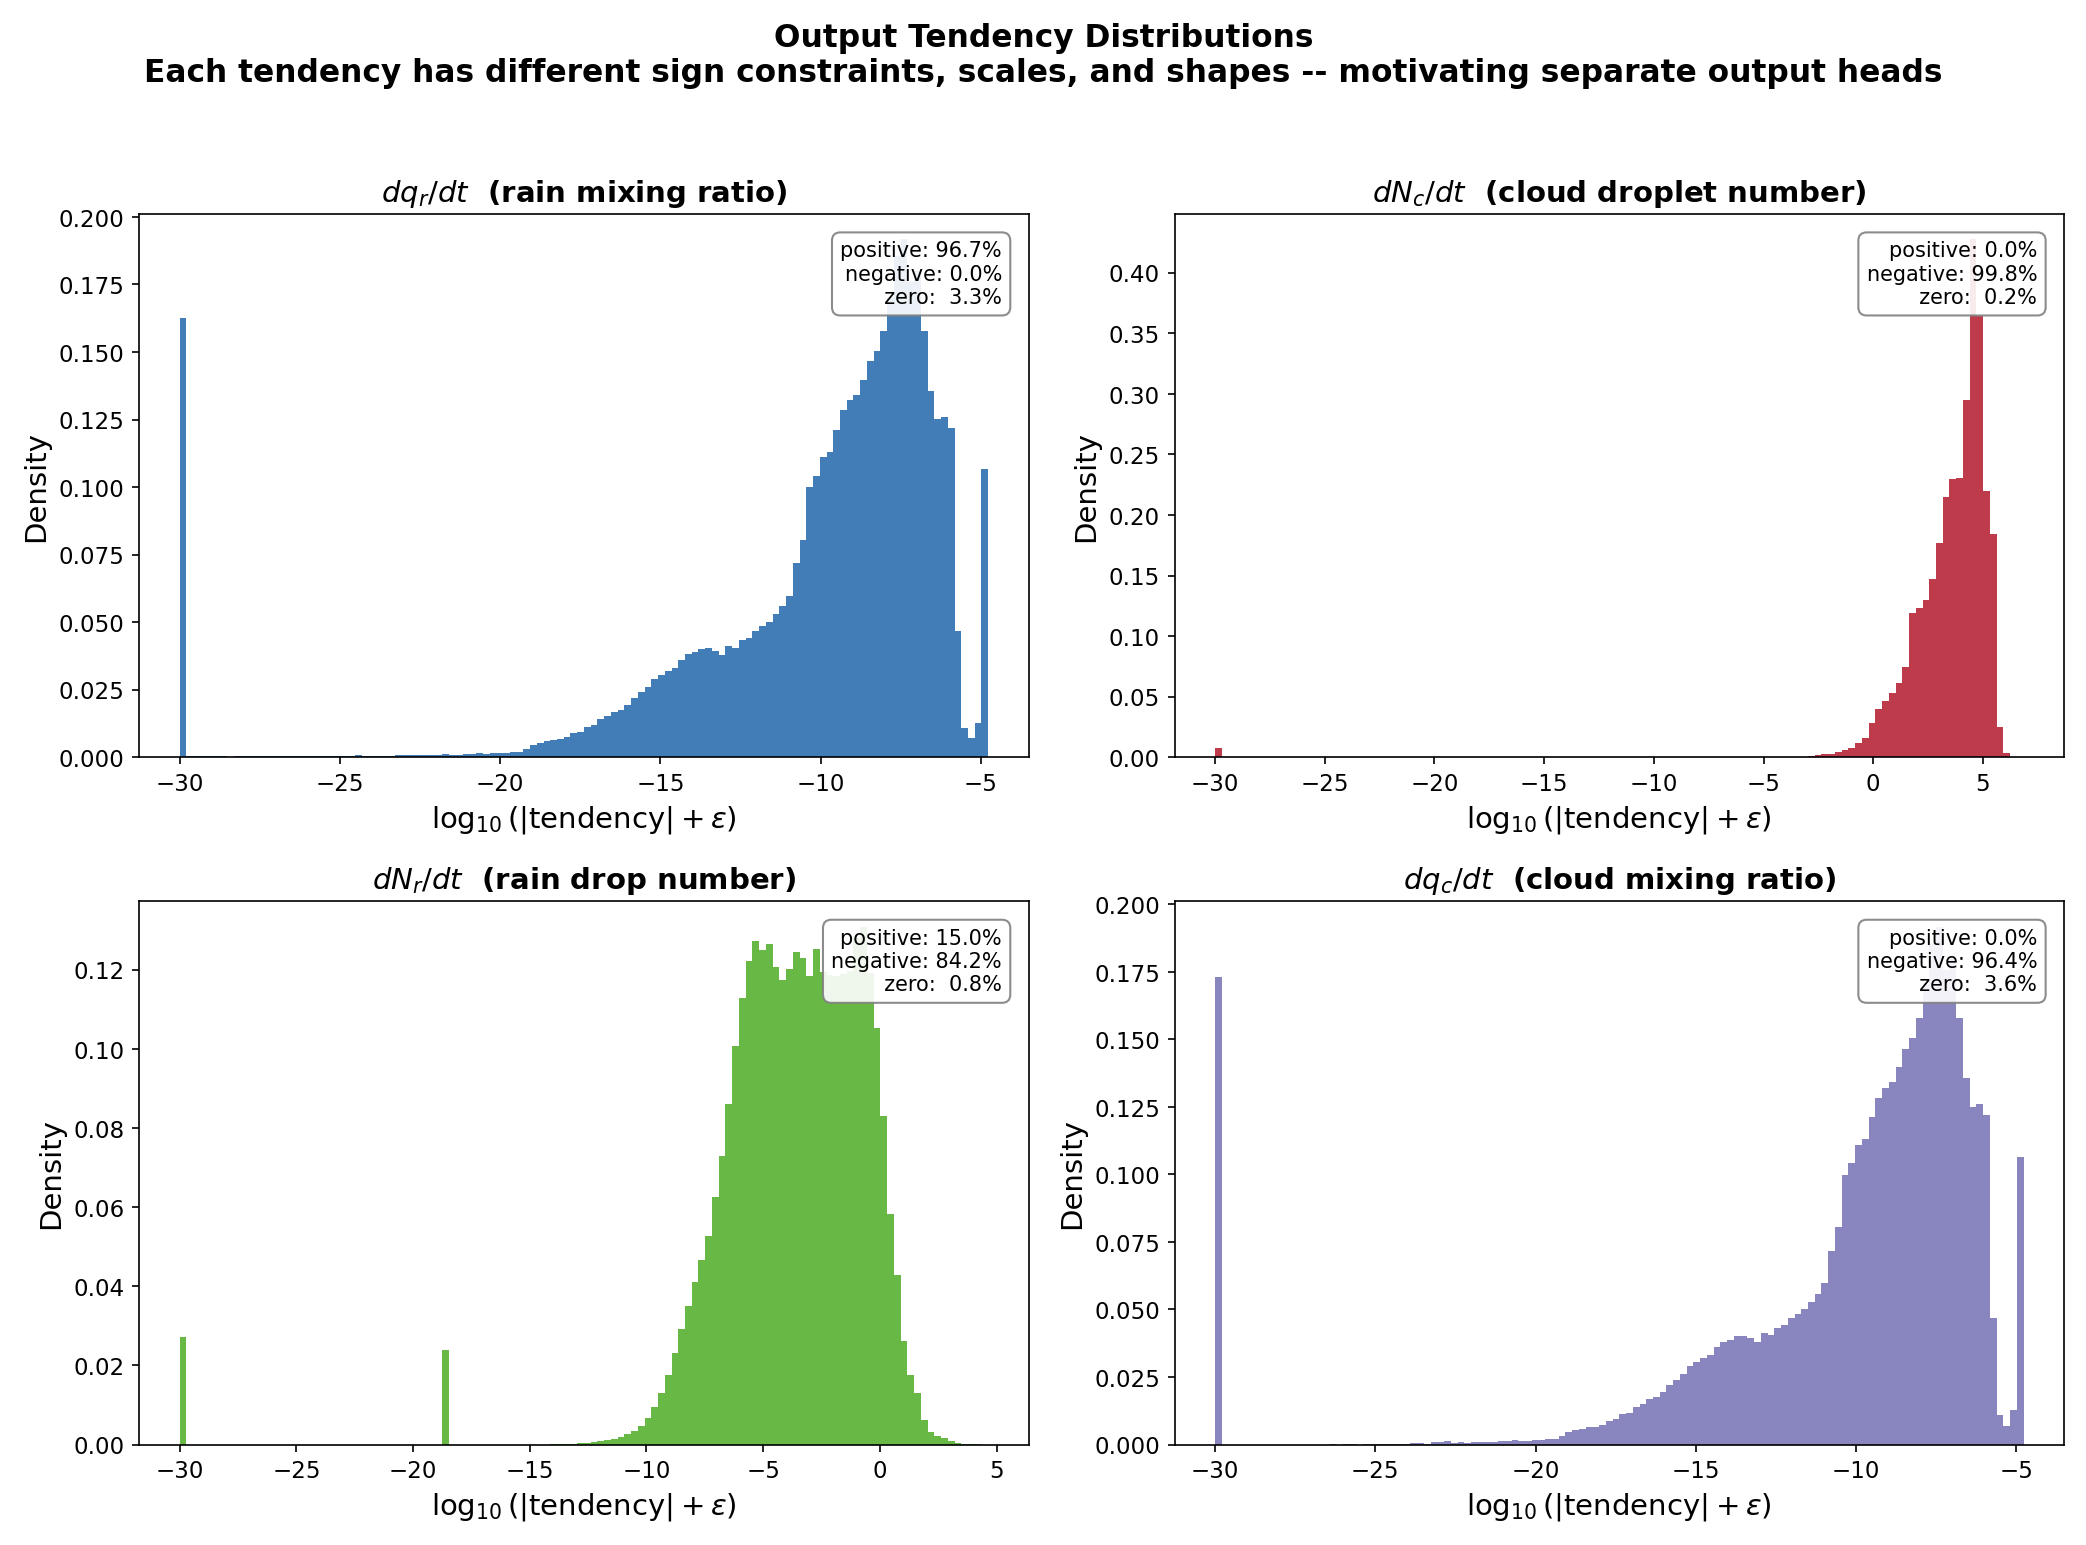

In [3]:
eps = 1e-30
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.ravel()

tend_keys = ['qrtend_TAU', 'nctend_TAU', 'nrtend_TAU', 'qctend_TAU']
colors_list = [COLORS['qrtend'], COLORS['nctend'], COLORS['nrtend'], COLORS['qctend']]

for ax, key, color in zip(axes, tend_keys, colors_list):
    vals = data[key].dropna().values
    pos_frac = np.mean(vals > 0) * 100
    neg_frac = np.mean(vals < 0) * 100
    zero_frac = np.mean(vals == 0) * 100

    log_abs = np.log10(np.abs(vals) + eps)
    ax.hist(log_abs, bins=120, color=color, alpha=0.85, edgecolor='none', density=True)

    sign_text = (f"positive: {pos_frac:.1f}%\n"
                 f"negative: {neg_frac:.1f}%\n"
                 f"  zero:  {zero_frac:.1f}%")
    ax.text(0.97, 0.95, sign_text, transform=ax.transAxes,
            va='top', ha='right', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.4', fc='white', ec='gray', alpha=0.9))

    ax.set_title(TENDENCY_LABELS[key], fontsize=14, fontweight='bold')
    ax.set_xlabel(r'$\log_{10}(|\mathrm{tendency}| + \epsilon)$')
    ax.set_ylabel('Density')

fig.suptitle('Output Tendency Distributions\n'
             'Each tendency has different sign constraints, scales, and shapes '
             '-- motivating separate output heads',
             fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig1_tendency_distributions.png')
plt.show()

---
## Input Sensitivity Heterogeneity

**Design choice:** Separate per-tendency heads branching from a shared backbone,
rather than a monolithic fully-connected output layer.

**Data-driven argument:** Each tendency has a *different correlation fingerprint*
with the 11 input features.  In a monolithic output layer, gradients from all 4
outputs compete to shape the same final weight matrix (gradient interference).
With separate heads, each can learn its own input-output mapping independently.

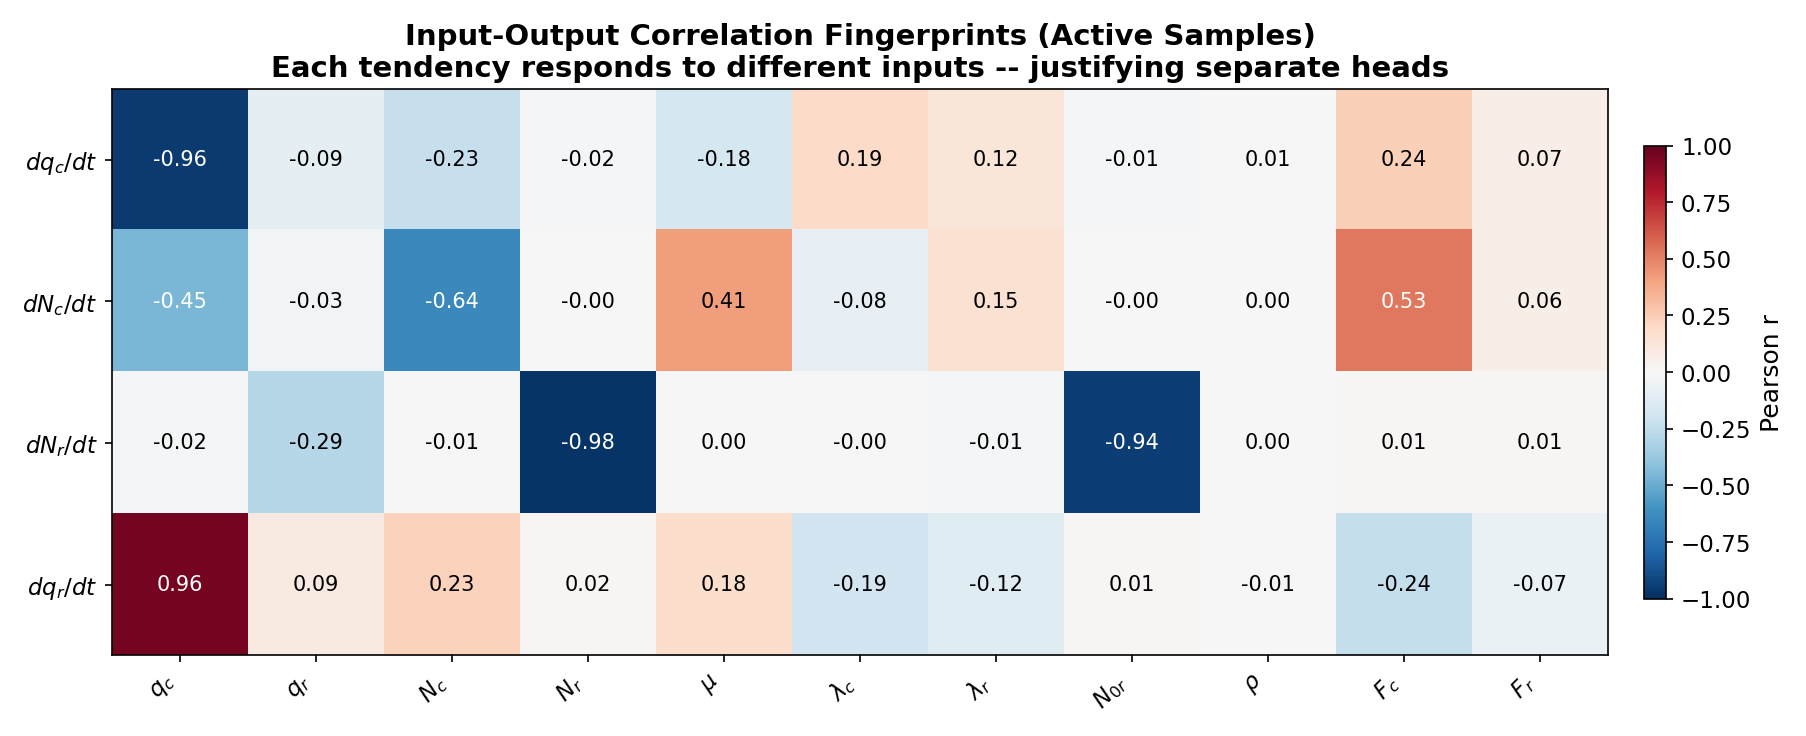

In [4]:
# Compute on active data (nonzero tendencies) to avoid dilution by quiescent zeros
active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
active = data.loc[active_mask]

corr_matrix = np.zeros((len(OUTPUT_COLS), len(INPUT_COLS)))
for i, out_col in enumerate(OUTPUT_COLS):
    for j, in_col in enumerate(INPUT_COLS):
        corr_matrix[i, j] = active[[in_col, out_col]].corr().iloc[0, 1]

fig, ax = plt.subplots(figsize=(13, 5))
im = ax.imshow(corr_matrix, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(INPUT_COLS)))
ax.set_xticklabels([INPUT_LABELS[c] for c in INPUT_COLS], rotation=45, ha='right')
ax.set_yticks(range(len(OUTPUT_COLS)))
ax.set_yticklabels([OUTPUT_LABELS_SHORT[c] for c in OUTPUT_COLS])

for i in range(corr_matrix.shape[0]):
    for j in range(corr_matrix.shape[1]):
        val = corr_matrix[i, j]
        color = 'white' if abs(val) > 0.45 else 'black'
        ax.text(j, i, f'{val:.2f}', ha='center', va='center', fontsize=10, color=color)

cbar = fig.colorbar(im, ax=ax, shrink=0.8, pad=0.02)
cbar.set_label('Pearson r', fontsize=12)

ax.set_title('Input-Output Correlation Fingerprints (Active Samples)\n'
             'Each tendency responds to different inputs -- justifying separate heads',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig2_correlation_fingerprints.png')
plt.show()

---
## Active vs Quiescent Regimes
**Saved figures:** `figures/fig3a_active_quiescent_physical.png` (physical space) and `figures/fig3b_active_quiescent_log.png` (log space, consistent with training transforms).

**Design choice:** Filter training data to cloud-active samples
(QC\_TAU\_in > 10$^{-6}$, cloud fraction > 0.01) and optionally use a
classification head to detect active vs quiescent regimes.

**Data-driven argument:** In quiescent conditions (below the thresholds), all
output tendencies collapse to near-zero regardless of input values -- there is
no learnable signal.  In active conditions, structured nonlinear input-output
relationships emerge.  The two regimes have fundamentally different mappings, so
mixing them would dilute the model's ability to learn the active-regime physics.

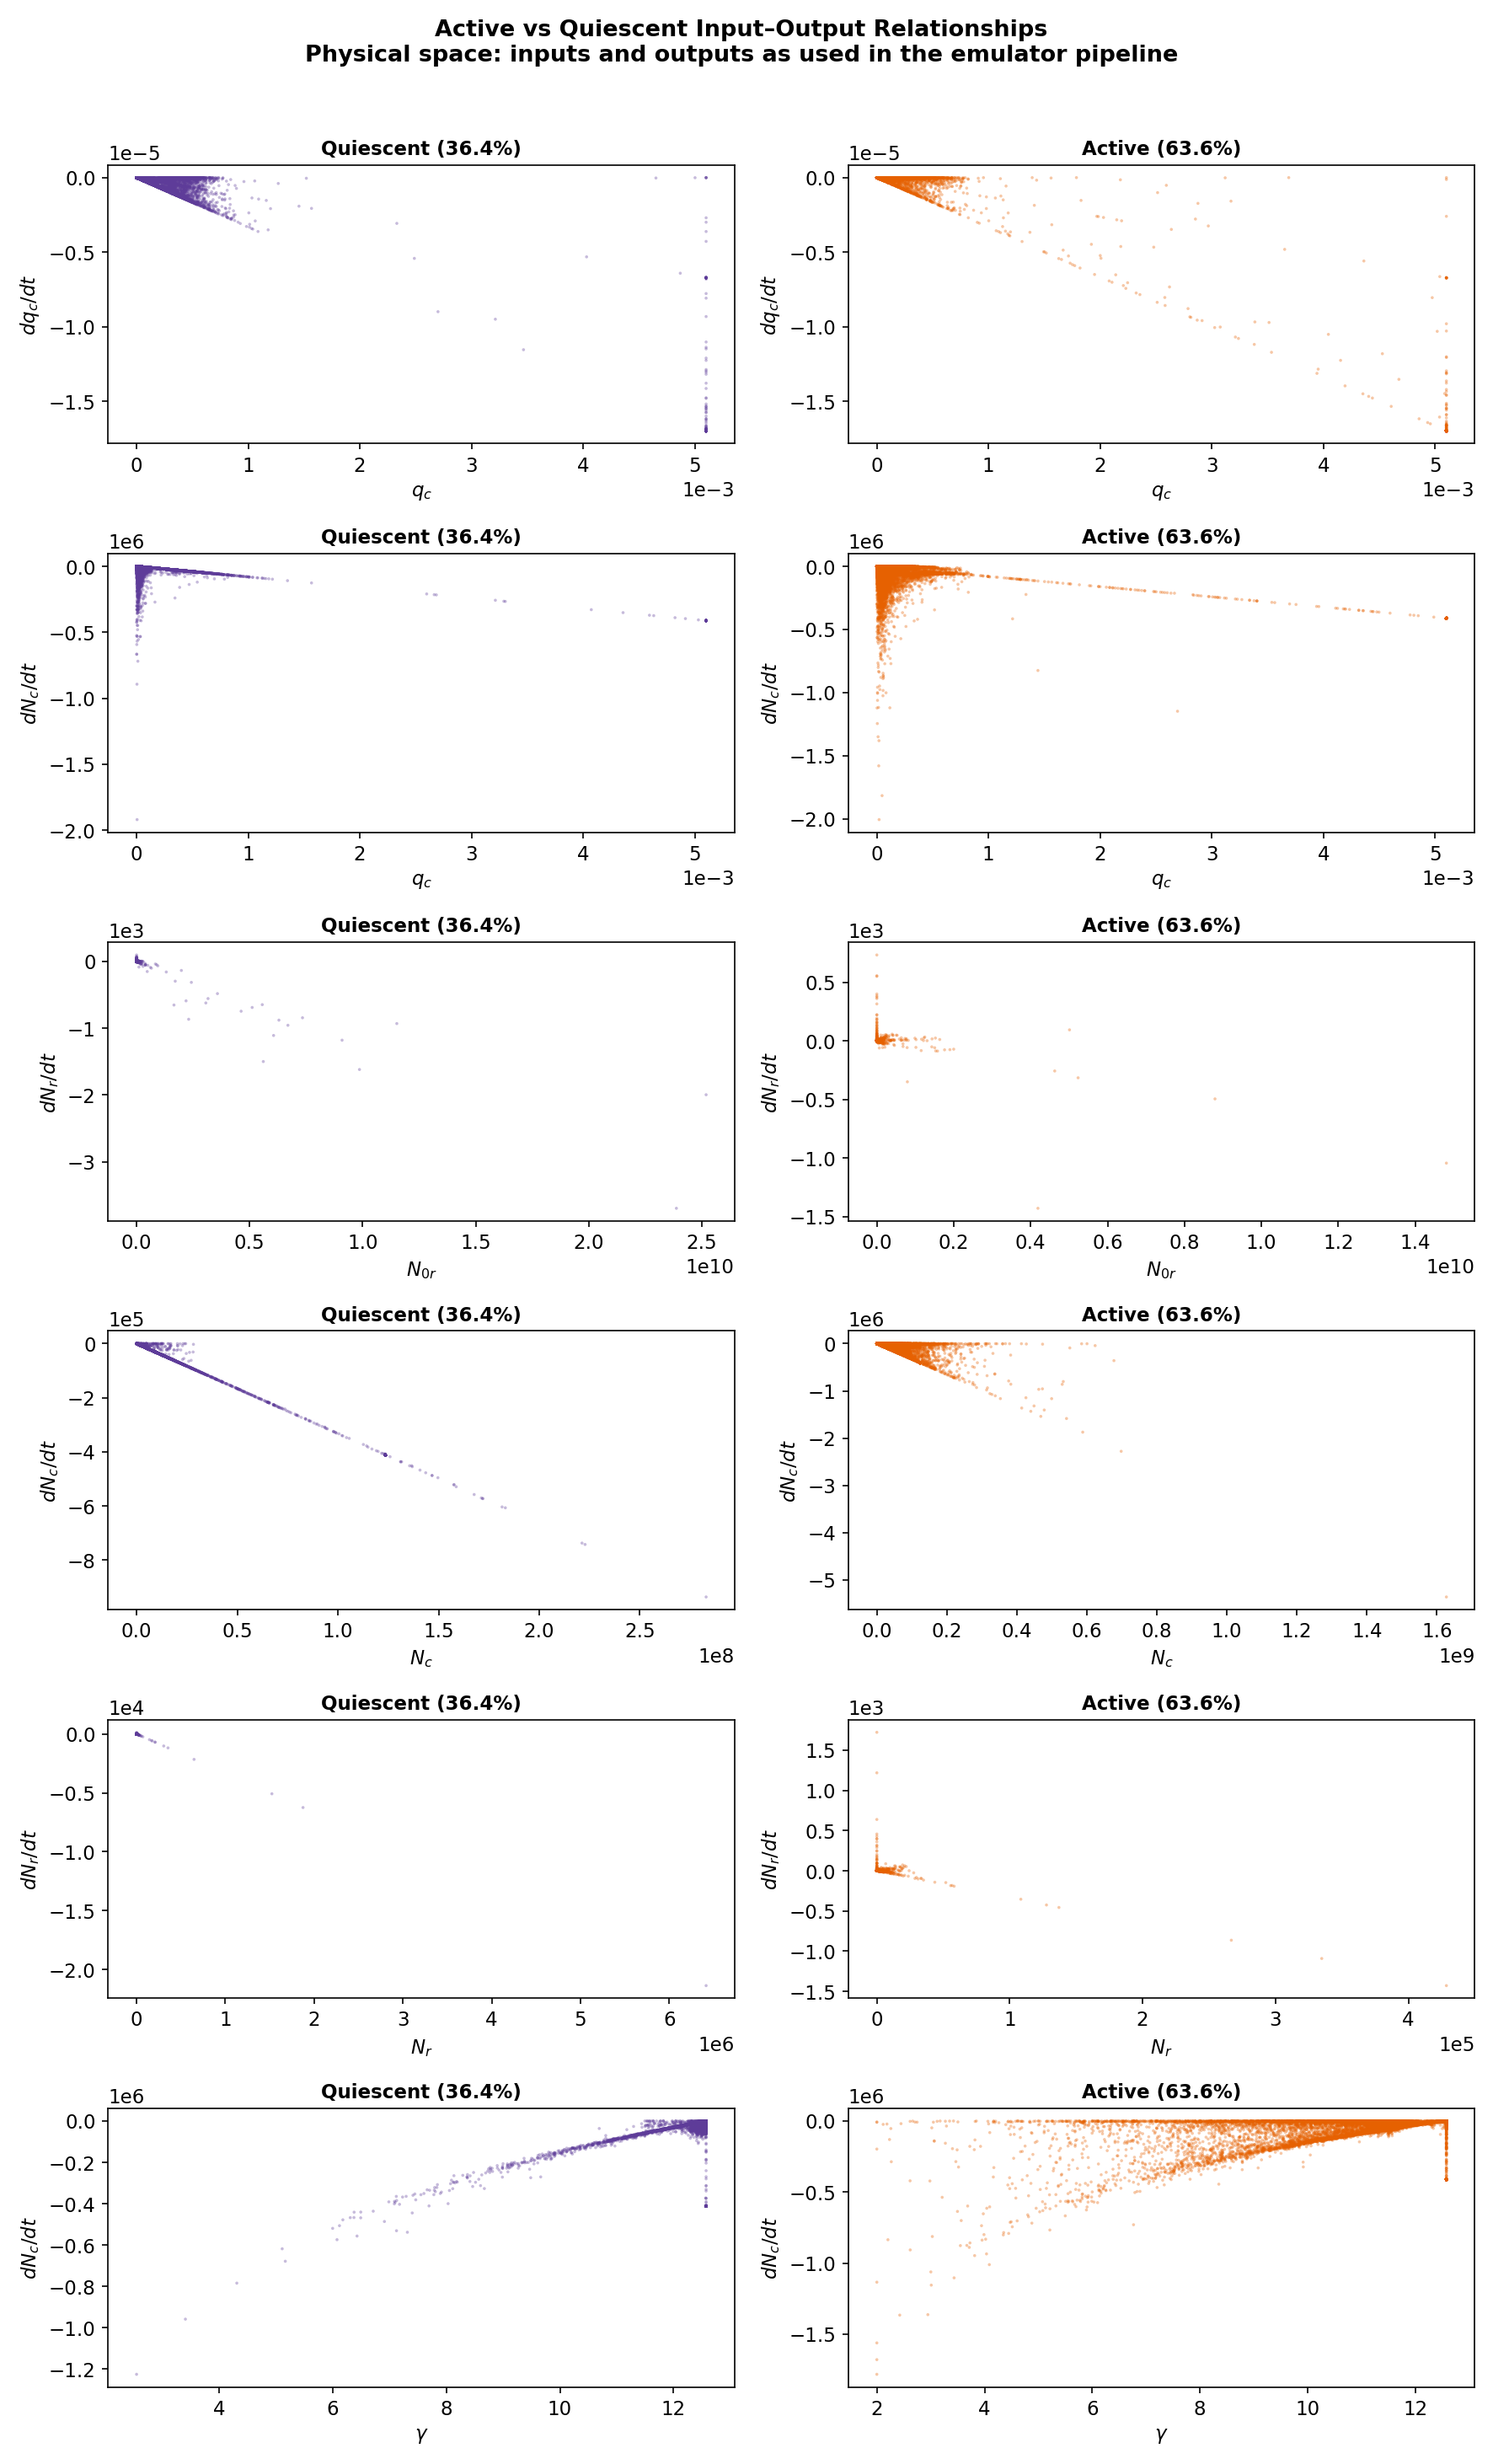

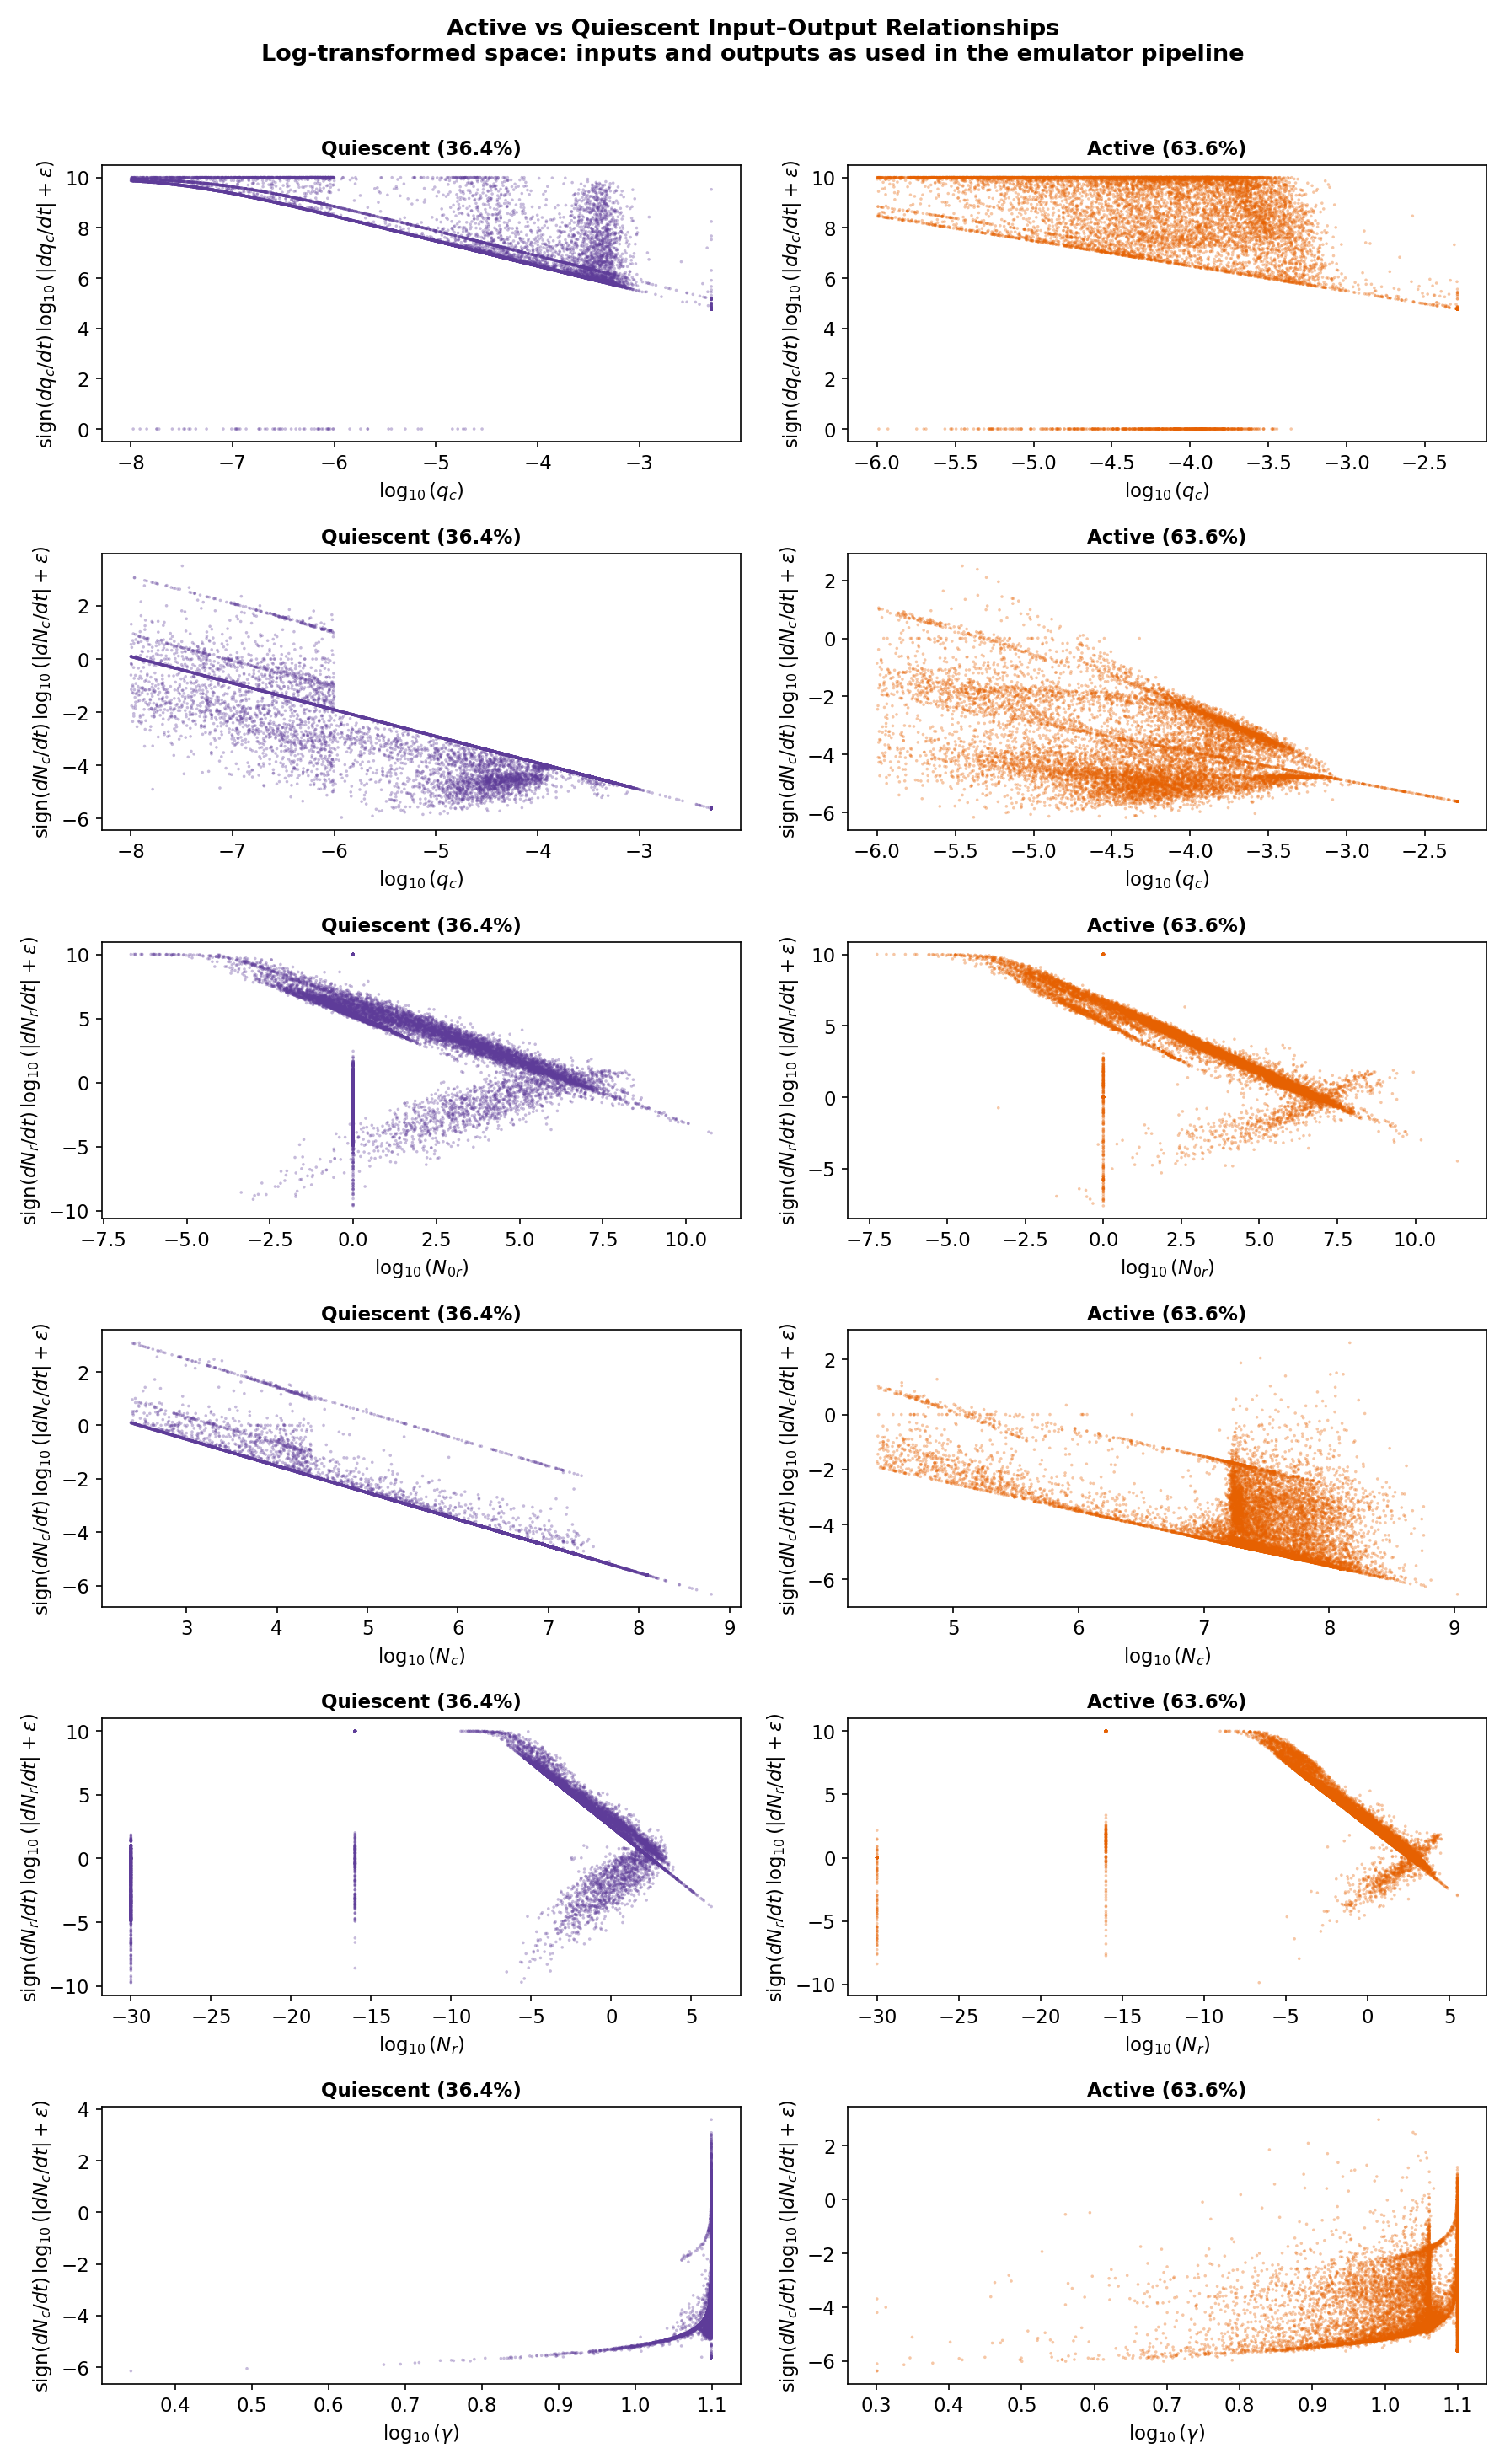

In [5]:
active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
quiescent_mask = ~active_mask
frac_active = active_mask.sum() / len(data) * 100
frac_quiescent = quiescent_mask.sum() / len(data) * 100

EPS_LOG = 1e-10
EPS_X = 1e-30


def sign_log10(y):
    return np.sign(y) * np.log10(np.abs(y) + EPS_LOG)


def log10_pos(x):
    return np.log10(np.maximum(x, EPS_X))


# (input_col, output_col, x_label_phys, y_label_phys, x_label_log, y_label_log)
PAIR_ROWS = [
    ('QC_TAU_in', 'qctend_TAU', r'$q_c$', r'$dq_c/dt$',
     r'$\log_{10}(q_c)$', r'$\mathrm{sign}(dq_c/dt)\,\log_{10}(|dq_c/dt|+\epsilon)$'),
    ('QC_TAU_in', 'nctend_TAU', r'$q_c$', r'$dN_c/dt$',
     r'$\log_{10}(q_c)$', r'$\mathrm{sign}(dN_c/dt)\,\log_{10}(|dN_c/dt|+\epsilon)$'),
    ('N0R', 'nrtend_TAU', r'$N_{0r}$', r'$dN_r/dt$',
     r'$\log_{10}(N_{0r})$', r'$\mathrm{sign}(dN_r/dt)\,\log_{10}(|dN_r/dt|+\epsilon)$'),
    ('NC_TAU_in', 'nctend_TAU', r'$N_c$', r'$dN_c/dt$',
     r'$\log_{10}(N_c)$', r'$\mathrm{sign}(dN_c/dt)\,\log_{10}(|dN_c/dt|+\epsilon)$'),
    ('NR_TAU_in', 'nrtend_TAU', r'$N_r$', r'$dN_r/dt$',
     r'$\log_{10}(N_r)$', r'$\mathrm{sign}(dN_r/dt)\,\log_{10}(|dN_r/dt|+\epsilon)$'),
    ('PGAM', 'nctend_TAU', r'$\gamma$', r'$dN_c/dt$',
     r'$\log_{10}(\gamma)$', r'$\mathrm{sign}(dN_c/dt)\,\log_{10}(|dN_c/dt|+\epsilon)$'),
]

np.random.seed(42)
N_SCATTER = 12_000


def scatter_active_quiescent(physical=True):
    fig, axes = plt.subplots(len(PAIR_ROWS), 2, figsize=(12, 3.2 * len(PAIR_ROWS)))
    if len(PAIR_ROWS) == 1:
        axes = np.array([axes])
    for row, rowdef in enumerate(PAIR_ROWS):
        in_col, out_col = rowdef[0], rowdef[1]
        xl_p, yl_p, xl_l, yl_l = rowdef[2], rowdef[3], rowdef[4], rowdef[5]
        for col, (mask, title_suffix, color, frac) in enumerate([
            (quiescent_mask, 'Quiescent', COLORS['quiescent'], frac_quiescent),
            (active_mask, 'Active', COLORS['active'], frac_active),
        ]):
            ax = axes[row, col]
            idx = np.where(mask)[0]
            if len(idx) > N_SCATTER:
                idx = np.random.choice(idx, N_SCATTER, replace=False)
            x = data[in_col].iloc[idx].values.astype(np.float64)
            y = data[out_col].iloc[idx].values.astype(np.float64)
            if physical:
                ax.scatter(x, y, s=3, alpha=0.35, c=color, rasterized=True, edgecolors='none')
                ax.set_xlabel(xl_p, fontsize=11)
                ax.set_ylabel(yl_p, fontsize=11)
            else:
                ax.scatter(log10_pos(x), sign_log10(y), s=3, alpha=0.35, c=color,
                           rasterized=True, edgecolors='none')
                ax.set_xlabel(xl_l, fontsize=11)
                ax.set_ylabel(yl_l, fontsize=11)
            ax.set_title(f'{title_suffix} ({frac:.1f}%)', fontsize=11, fontweight='bold')
            ax.ticklabel_format(style='scientific', scilimits=(-3, 3), axis='both')
    mode = 'Physical space' if physical else 'Log-transformed space'
    fig.suptitle(
        'Active vs Quiescent Input–Output Relationships\n'
        f'{mode}: inputs and outputs as used in the emulator pipeline',
        fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()


scatter_active_quiescent(physical=True)
plt.savefig(FIG_DIR / 'fig3a_active_quiescent_physical.png')
plt.show()

scatter_active_quiescent(physical=False)
plt.savefig(FIG_DIR / 'fig3b_active_quiescent_log.png')
plt.show()


---
## Shared Backbone vs Predecessor Tree-of-ANNs

**Predecessor architecture:** The prior work used a tree of independent
per-tendency pipelines -- each tendency had its own ANN classifier
(e.g., "is dq$_r$/dt > 0?") followed by a separate ANN regressor.
This amounts to 3 independent feature-extraction pipelines with no shared
representation.

**Our architecture:** A single shared backbone extracts common features from the
input space, then separate lightweight heads specialize per tendency.

**Data-driven argument:**
- The input features drive *all* tendencies (shared information), as shown by the
  correlation fingerprints above.  Shared feature extraction is therefore efficient.
- The tendencies themselves are correlated through their shared dependence on inputs.
  PCA on the input space reveals that a small number of shared components explain
  substantial variance in *all* tendencies -- so a shared backbone is well-suited.
- The predecessor duplicates feature extraction 3x and cannot transfer learned
  representations across tendencies. Our design is more parameter-efficient and
  benefits from multi-task regularization.

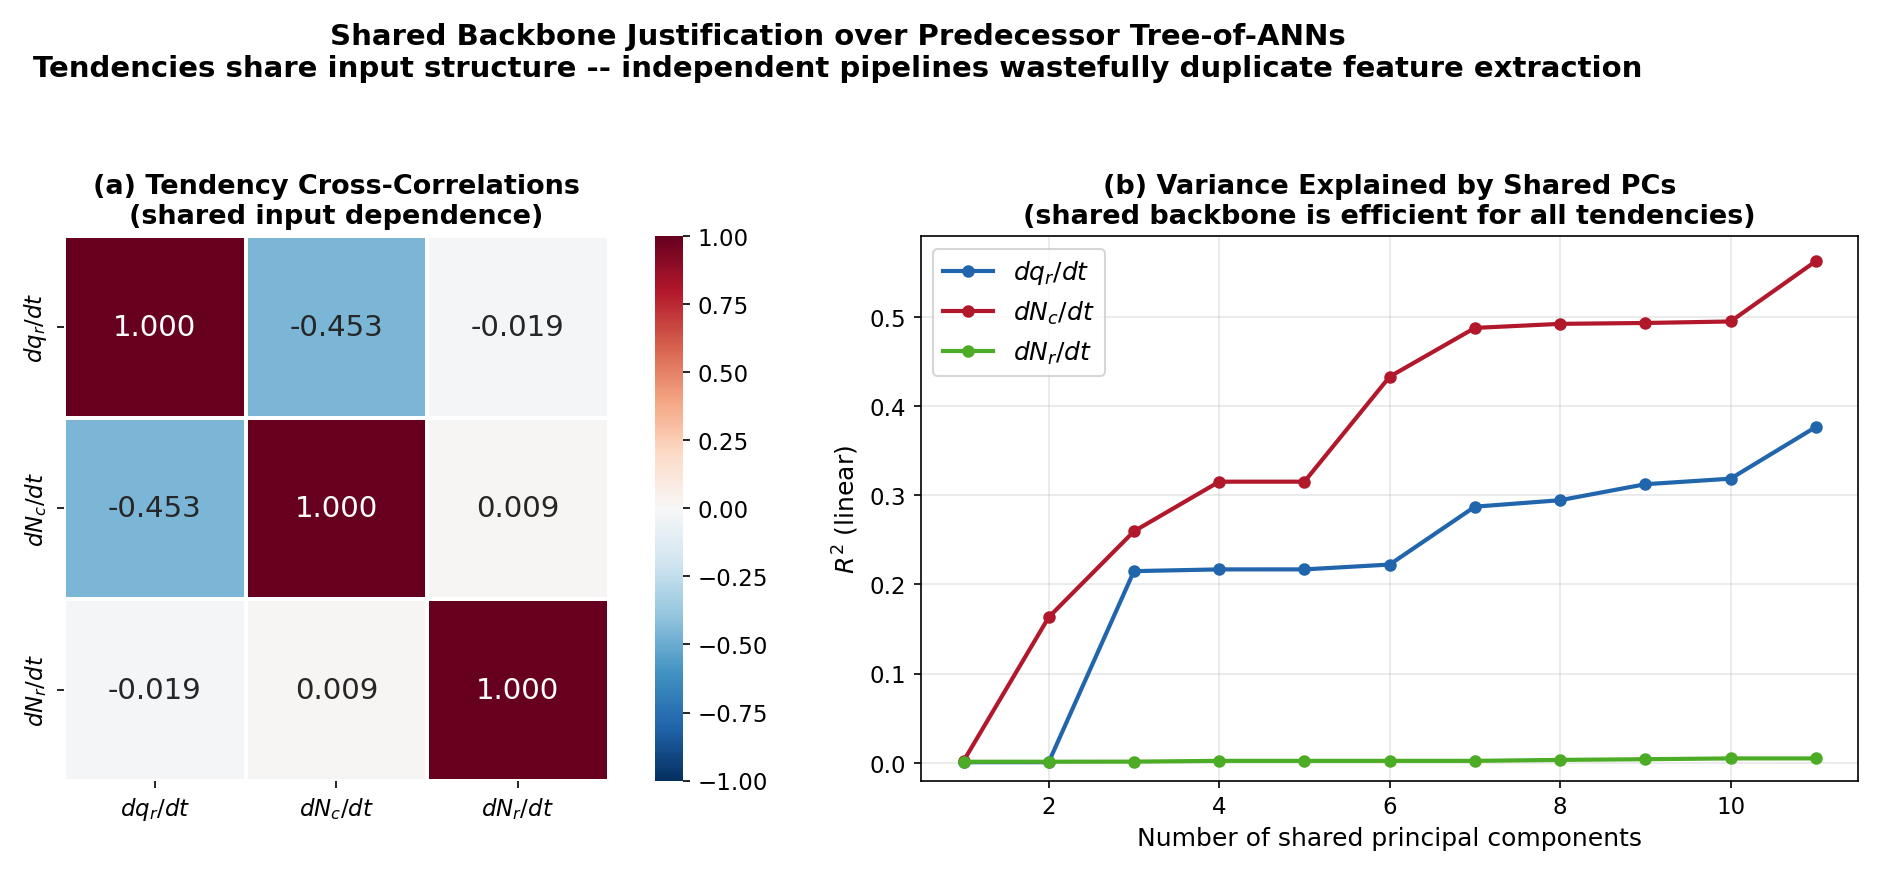

In [6]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
active = data.loc[active_mask].copy()

# Log-transform the inputs that span orders of magnitude (same as training pipeline)
log_cols = ['QC_TAU_in', 'QR_TAU_in', 'NC_TAU_in', 'NR_TAU_in', 'LAMC', 'LAMR', 'N0R']
X = active[INPUT_COLS].copy()
for c in log_cols:
    X[c] = np.log10(X[c].clip(lower=1e-30))
X = X.replace([np.inf, -np.inf], np.nan).dropna()

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pca = PCA()
X_pca = pca.fit_transform(X_scaled)

# Compute R^2 of each tendency vs cumulative PCs
Y = active.loc[X.index, OUTPUT_COLS]
tend_names = ['qrtend_TAU', 'nctend_TAU', 'nrtend_TAU']
r2_by_npc = {t: [] for t in tend_names}

for n_comp in range(1, len(INPUT_COLS) + 1):
    X_sub = X_pca[:, :n_comp]
    for t in tend_names:
        y = Y[t].values
        # R^2 via correlation of OLS fit
        coeffs = np.linalg.lstsq(
            np.column_stack([X_sub, np.ones(len(X_sub))]), y, rcond=None
        )[0]
        y_pred = np.column_stack([X_sub, np.ones(len(X_sub))]) @ coeffs
        ss_res = np.sum((y - y_pred) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot
        r2_by_npc[t].append(r2)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5.5))

# Panel A: Inter-tendency correlation through shared inputs
tend_corr = active[tend_names].corr()
mask = np.triu(np.ones_like(tend_corr, dtype=bool), k=1)
sns.heatmap(tend_corr, annot=True, fmt='.3f', cmap='RdBu_r', vmin=-1, vmax=1,
            ax=ax1, square=True, linewidths=1, linecolor='white',
            xticklabels=[OUTPUT_LABELS_SHORT[c] for c in tend_names],
            yticklabels=[OUTPUT_LABELS_SHORT[c] for c in tend_names],
            annot_kws={'fontsize': 14})
ax1.set_title('(a) Tendency Cross-Correlations\n(shared input dependence)',
              fontsize=13, fontweight='bold')

# Panel B: Cumulative variance explained by shared PCs
color_map = {'qrtend_TAU': COLORS['qrtend'], 'nctend_TAU': COLORS['nctend'],
             'nrtend_TAU': COLORS['nrtend']}
for t in tend_names:
    ax2.plot(range(1, len(INPUT_COLS)+1), r2_by_npc[t],
             'o-', color=color_map[t], label=OUTPUT_LABELS_SHORT[t],
             linewidth=2, markersize=5)
ax2.set_xlabel('Number of shared principal components', fontsize=12)
ax2.set_ylabel(r'$R^2$ (linear)', fontsize=12)
ax2.set_title('(b) Variance Explained by Shared PCs\n'
              '(shared backbone is efficient for all tendencies)',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=12, frameon=True)
ax2.set_xlim(0.5, len(INPUT_COLS) + 0.5)
ax2.set_ylim(bottom=-0.02)
ax2.grid(True, alpha=0.3)

fig.suptitle('Shared Backbone Justification over Predecessor Tree-of-ANNs\n'
             'Tendencies share input structure -- independent pipelines '
             'wastefully duplicate feature extraction',
             fontsize=14, fontweight='bold', y=1.04)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig4_predecessor_comparison.png')
plt.show()

---
## Mass Conservation: qctend = -qrtend

**Design choice:** Hard-code qctend = -qrtend in the network architecture
instead of predicting both independently or adding a soft penalty term.

**Data-driven argument:** Cloud water loss equals rain water gain by mass
conservation. The data shows an exact (not approximate) anti-correlation
between qctend and qrtend. This physical invariant should be enforced by
construction, not learned -- reducing the effective output dimension from 4 to 3
and guaranteeing zero conservation error.

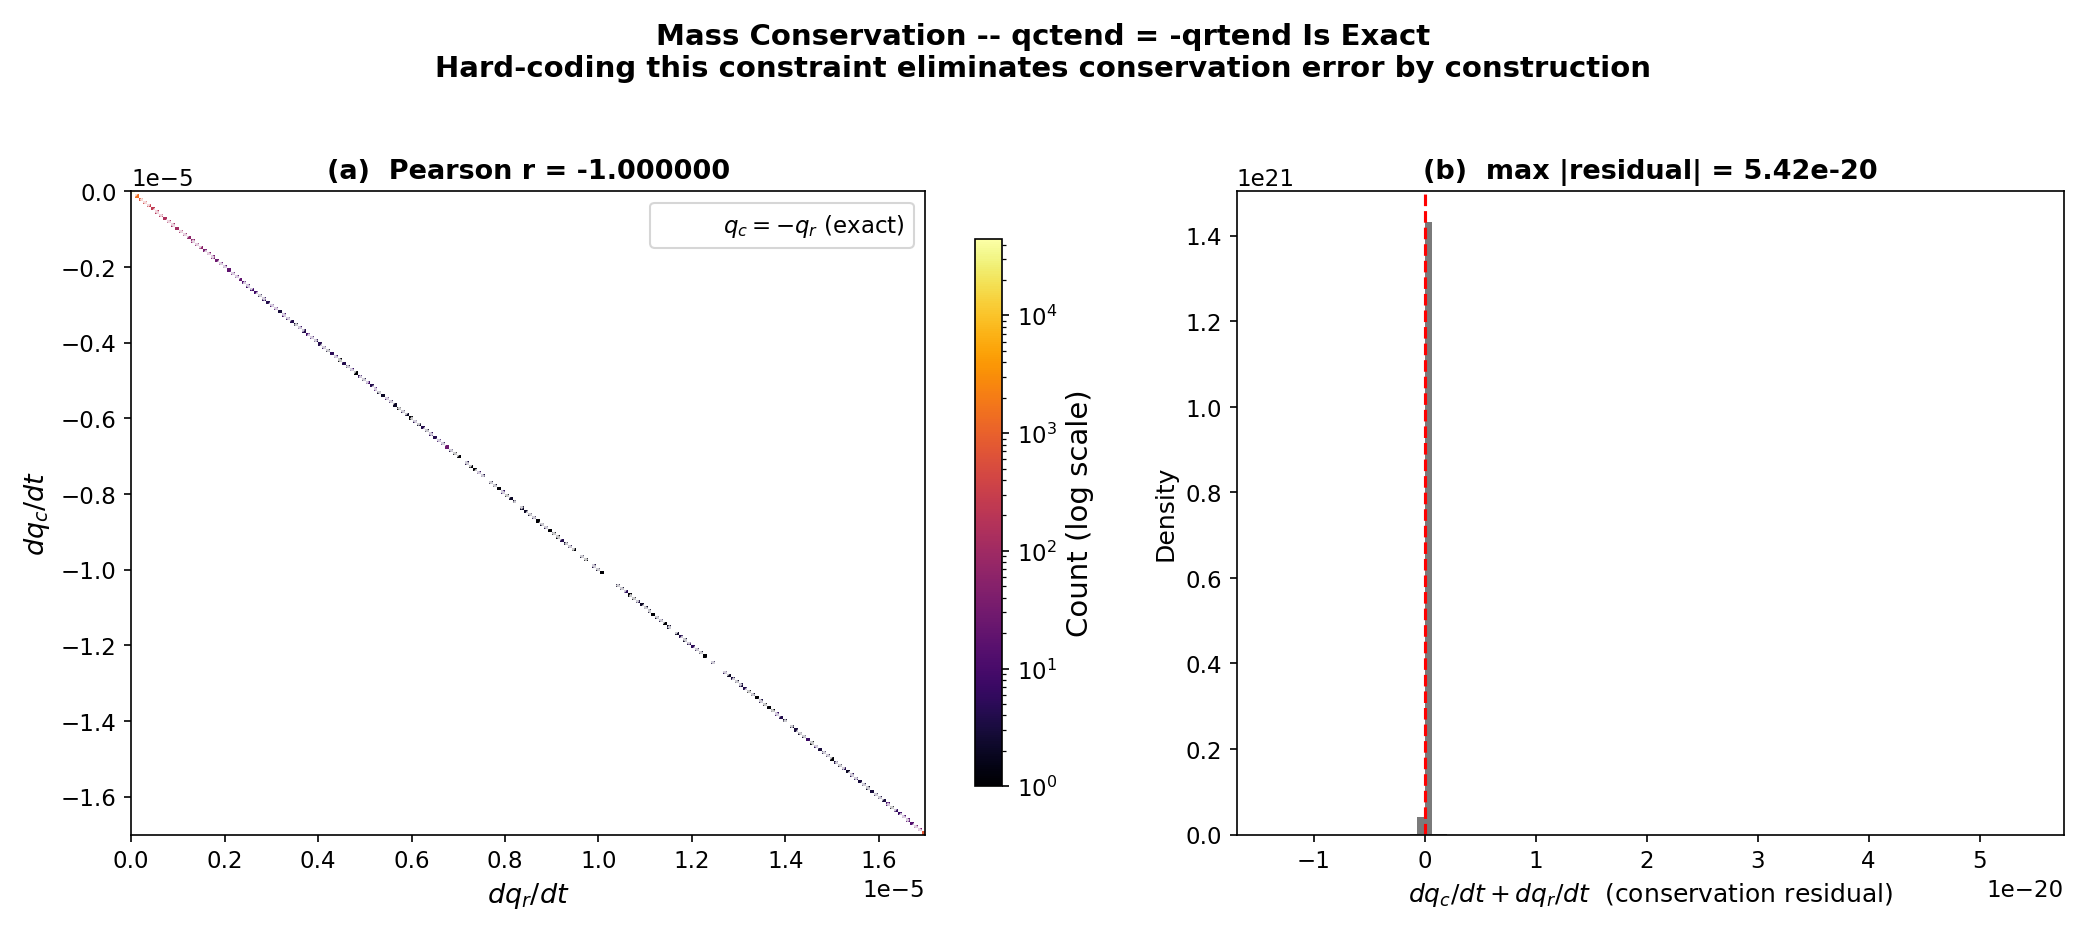

In [7]:
active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
active = data.loc[active_mask]

np.random.seed(42)
n_pts = min(50_000, len(active))
idx = np.random.choice(len(active), size=n_pts, replace=False)
qr = active['qrtend_TAU'].iloc[idx].values
qc = active['qctend_TAU'].iloc[idx].values

r_val = np.corrcoef(qr, qc)[0, 1]
residual = qc + qr
max_residual = np.max(np.abs(residual))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6), gridspec_kw={'width_ratios': [1.2, 1]})

# Panel A: density scatter
from matplotlib.colors import LogNorm
h = ax1.hist2d(qr, qc, bins=200, cmap='inferno', norm=LogNorm(), rasterized=True)
fig.colorbar(h[3], ax=ax1, label='Count (log scale)', shrink=0.85)

lims = [min(qr.min(), qc.min()), max(qr.max(), qc.max())]
ax1.plot(lims, [-l for l in lims], 'w--', linewidth=1.5, alpha=0.8, label='$q_c = -q_r$ (exact)')
ax1.set_xlabel(r'$dq_r/dt$', fontsize=13)
ax1.set_ylabel(r'$dq_c/dt$', fontsize=13)
ax1.set_title(f'(a)  Pearson r = {r_val:.6f}', fontsize=13, fontweight='bold')
ax1.legend(fontsize=11, loc='upper right')
ax1.ticklabel_format(style='scientific', scilimits=(-3, 3))

# Panel B: residual histogram
ax2.hist(residual, bins=100, color='#636363', edgecolor='none', alpha=0.85, density=True)
ax2.axvline(0, color='red', linestyle='--', linewidth=1.5)
ax2.set_xlabel(r'$dq_c/dt + dq_r/dt$  (conservation residual)', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title(f'(b)  max |residual| = {max_residual:.2e}', fontsize=13, fontweight='bold')
ax2.ticklabel_format(axis='x', style='scientific', scilimits=(-3, 3))

fig.suptitle('Mass Conservation -- qctend = -qrtend Is Exact\n'
             'Hard-coding this constraint eliminates conservation error by construction',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig5_mass_conservation.png')
plt.show()

---
## Log$_{10}$ Transform and Standard Scaling

**Design choice:** Apply log$_{10}$ transform to input hydrometeor variables
and sign-preserving log$_{10}$ to output tendencies before scaling and training.

**Data-driven argument:** Raw microphysical variables span 10+ orders of
magnitude with extreme right-skew.  Standard neural network training (with
StandardScaler normalization) struggles with such dynamic range.  Log-transform
compresses the scale and produces approximately Gaussian distributions
that are well-conditioned for gradient-based optimization.

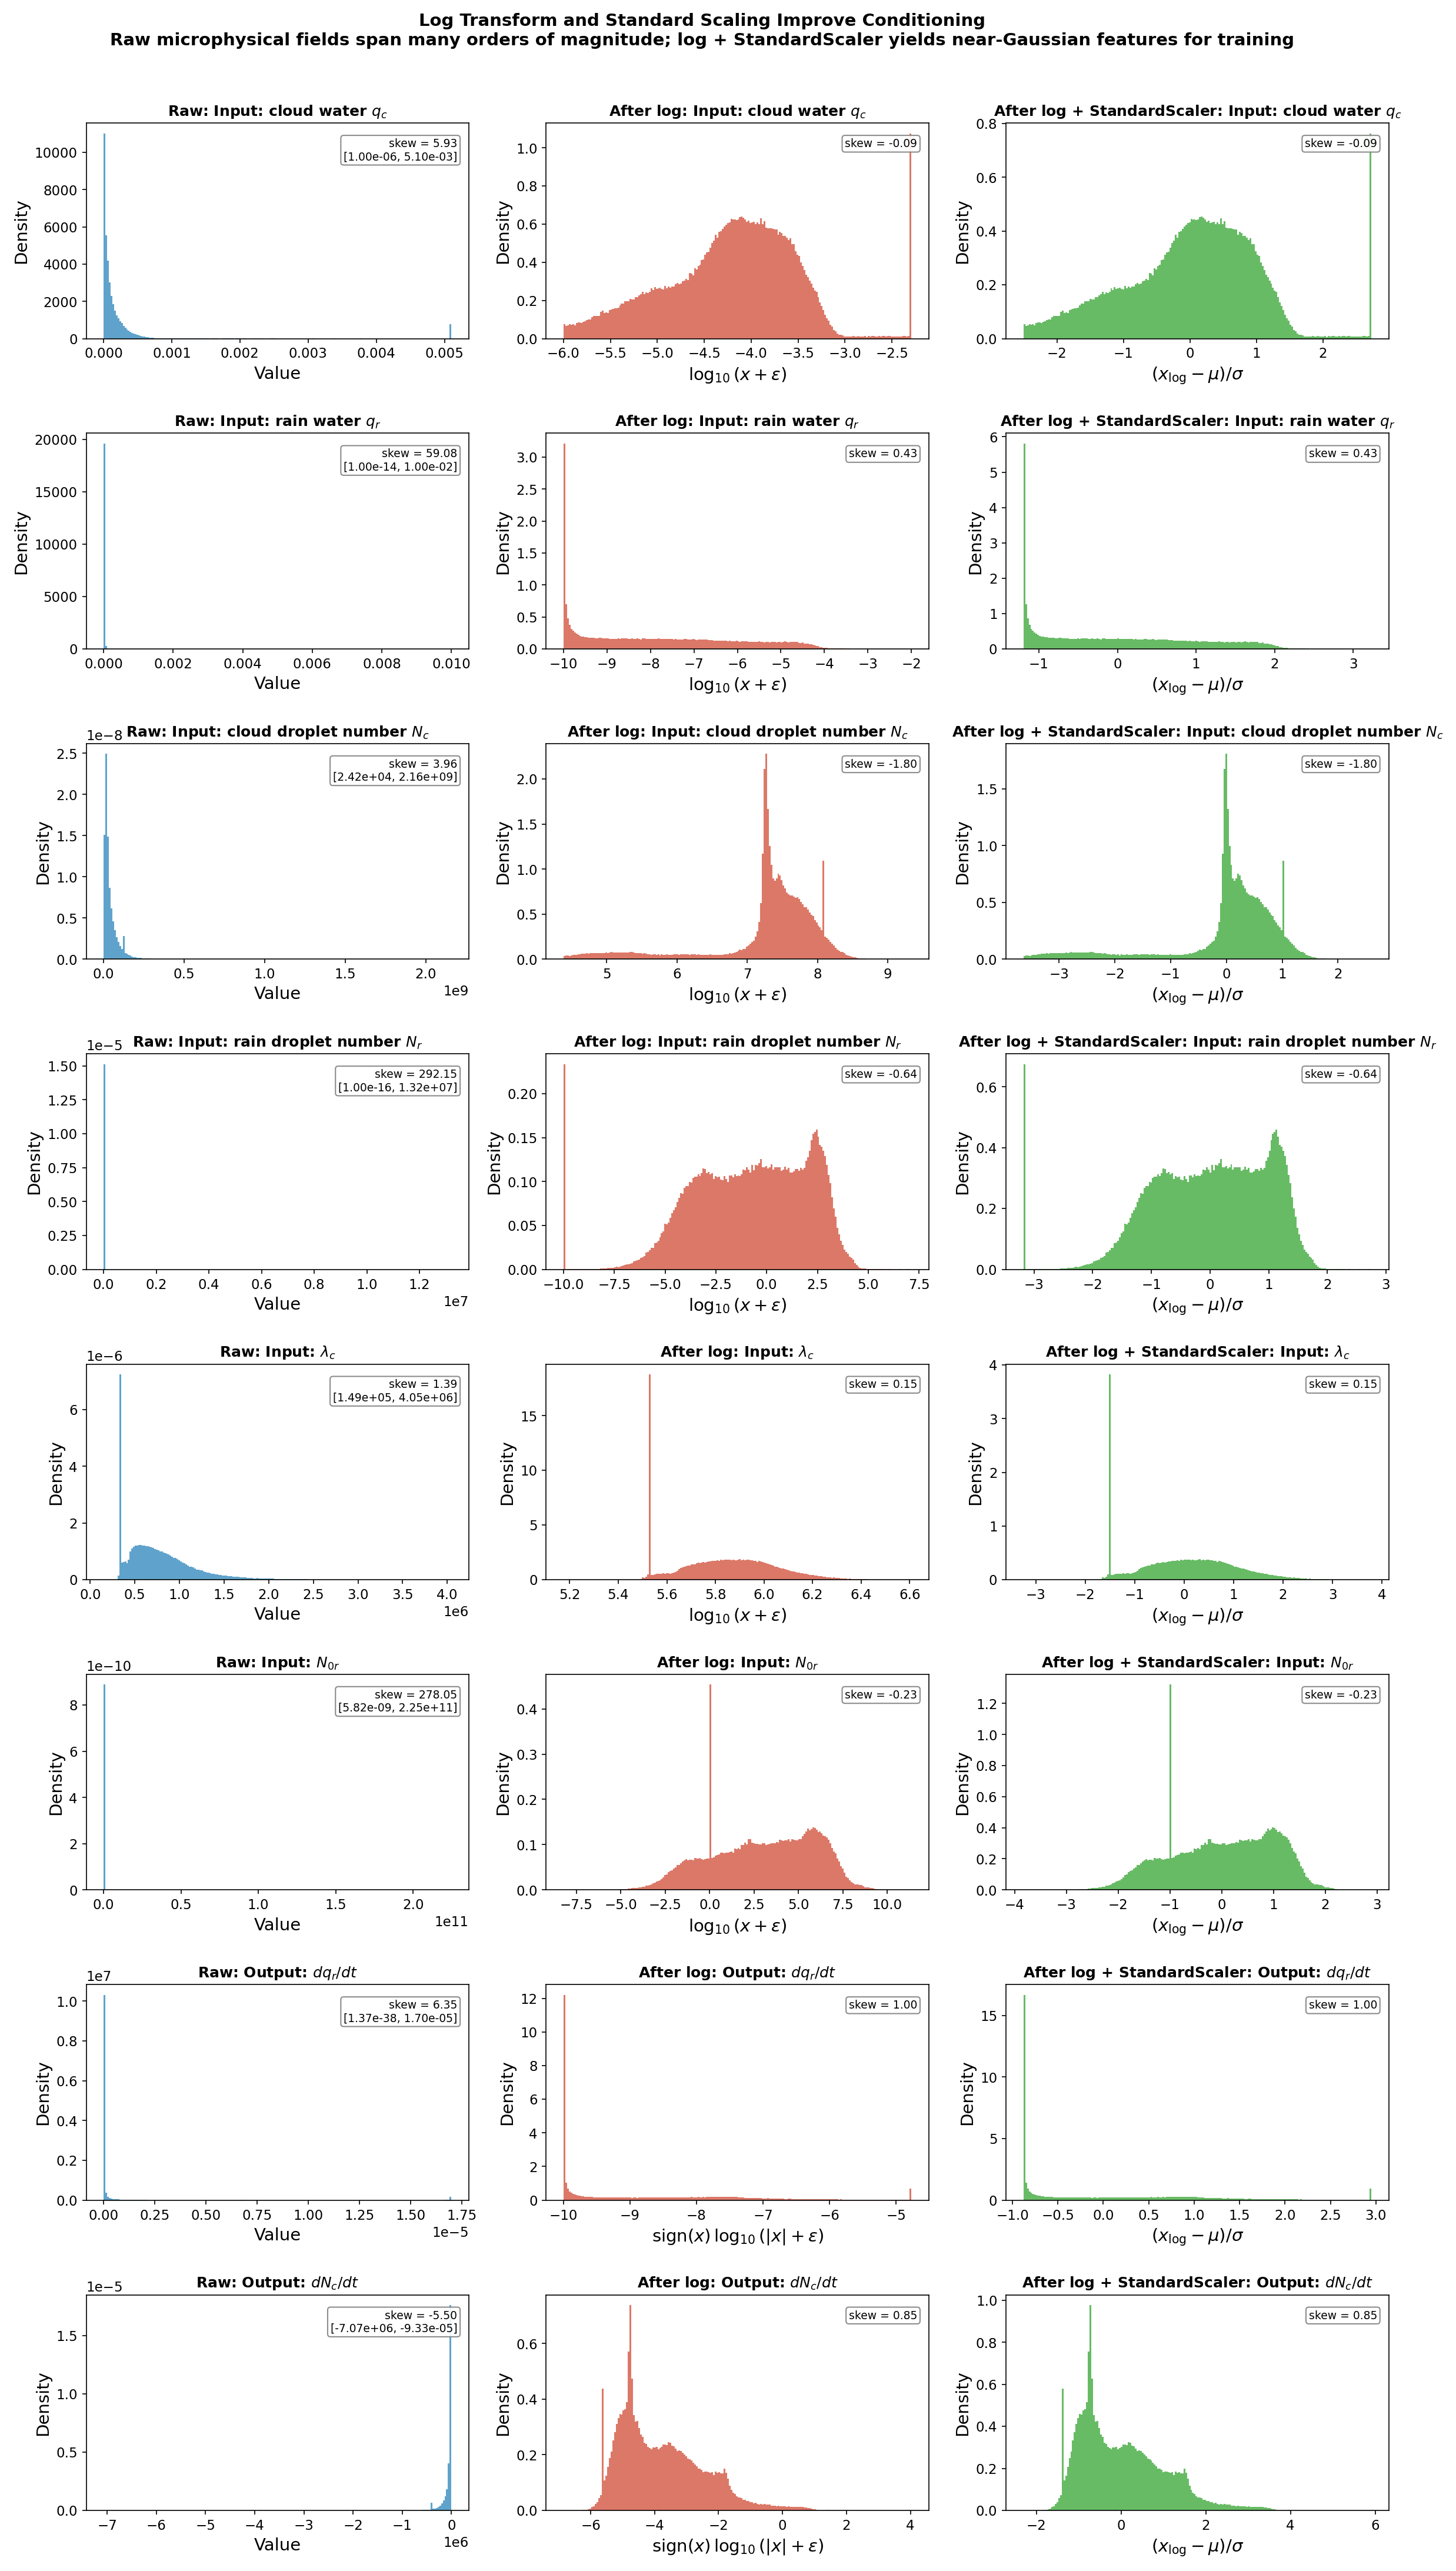

In [8]:
from sklearn.preprocessing import StandardScaler

active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
active = data.loc[active_mask]

# (column, subplot title, is_strictly_positive_for_log)
DEMO_VARS = [
    ('QC_TAU_in', r'Input: cloud water $q_c$', True),
    ('QR_TAU_in', r'Input: rain water $q_r$', True),
    ('NC_TAU_in', r'Input: cloud droplet number $N_c$', True),
    ('NR_TAU_in', r'Input: rain droplet number $N_r$', True),
    ('LAMC', r'Input: $\lambda_c$', True),
    ('N0R', r'Input: $N_{0r}$', True),
    ('qrtend_TAU', r'Output: $dq_r/dt$', False),
    ('nctend_TAU', r'Output: $dN_c/dt$', False),
]

fig, axes = plt.subplots(len(DEMO_VARS), 3, figsize=(16, 3.6 * len(DEMO_VARS)))
eps = 1e-10

for row, (col, label, is_positive) in enumerate(DEMO_VARS):
    vals = active[col].dropna().values
    finite = vals[np.isfinite(vals)]
    if is_positive:
        finite = finite[finite > 0]
    else:
        finite = finite[np.abs(finite) > 0]

    ax_raw, ax_log, ax_std = axes[row, 0], axes[row, 1], axes[row, 2]

    ax_raw.hist(finite, bins=200, color='#4393c3', edgecolor='none', alpha=0.85, density=True)
    ax_raw.set_title(f'Raw: {label}', fontsize=12, fontweight='bold')
    ax_raw.set_xlabel('Value')
    ax_raw.set_ylabel('Density')
    skew = stats.skew(finite)
    ax_raw.text(0.97, 0.93, f'skew = {skew:.2f}\n[{finite.min():.2e}, {finite.max():.2e}]',
                transform=ax_raw.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

    if is_positive:
        log_vals = np.log10(finite + eps)
        tlab = r'$\log_{10}(x+\epsilon)$'
    else:
        log_vals = np.sign(finite) * np.log10(np.abs(finite) + eps)
        tlab = r'$\mathrm{sign}(x)\,\log_{10}(|x|+\epsilon)$'

    ax_log.hist(log_vals, bins=200, color='#d6604d', edgecolor='none', alpha=0.85, density=True)
    ax_log.set_title(f'After log: {label}', fontsize=12, fontweight='bold')
    ax_log.set_xlabel(tlab)
    ax_log.set_ylabel('Density')
    ax_log.text(0.97, 0.93, f'skew = {stats.skew(log_vals):.2f}',
                transform=ax_log.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

    scaler = StandardScaler()
    scaled = scaler.fit_transform(log_vals.reshape(-1, 1)).ravel()
    ax_std.hist(scaled, bins=200, color='#4daf4a', edgecolor='none', alpha=0.85, density=True)
    ax_std.set_title(f'After log + StandardScaler: {label}', fontsize=12, fontweight='bold')
    ax_std.set_xlabel(r'$(x_{\mathrm{log}} - \mu) / \sigma$')
    ax_std.set_ylabel('Density')
    ax_std.text(0.97, 0.93, f'skew = {stats.skew(scaled):.2f}',
                transform=ax_std.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.25', fc='white', ec='gray', alpha=0.9))

fig.suptitle(
    'Log Transform and Standard Scaling Improve Conditioning\n'
    'Raw microphysical fields span many orders of magnitude; '
    'log + StandardScaler yields near-Gaussian features for training',
    fontsize=14, fontweight='bold', y=1.008)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig6_log_transform.png')
plt.show()


---
## arcsinh Transform for nrtend

**Design choice:** Use arcsinh(x/c) instead of sign-preserving log$_{10}$ for the
rain droplet number tendency (nrtend).

**Data-driven argument:** Unlike the other tendencies which have a definite sign
(qrtend $\geq$ 0, nctend $\leq$ 0), nrtend takes positive *and* negative values with
a substantial fraction near zero.  The sign-preserving log transform
sign(x) $\cdot$ log$_{10}$(|x| + $\epsilon$) creates a bimodal distribution with a
discontinuity at zero -- a pathological loss landscape for neural networks.
The inverse hyperbolic sine arcsinh(x/c) is smooth through zero and produces a
single-mode, well-behaved distribution.

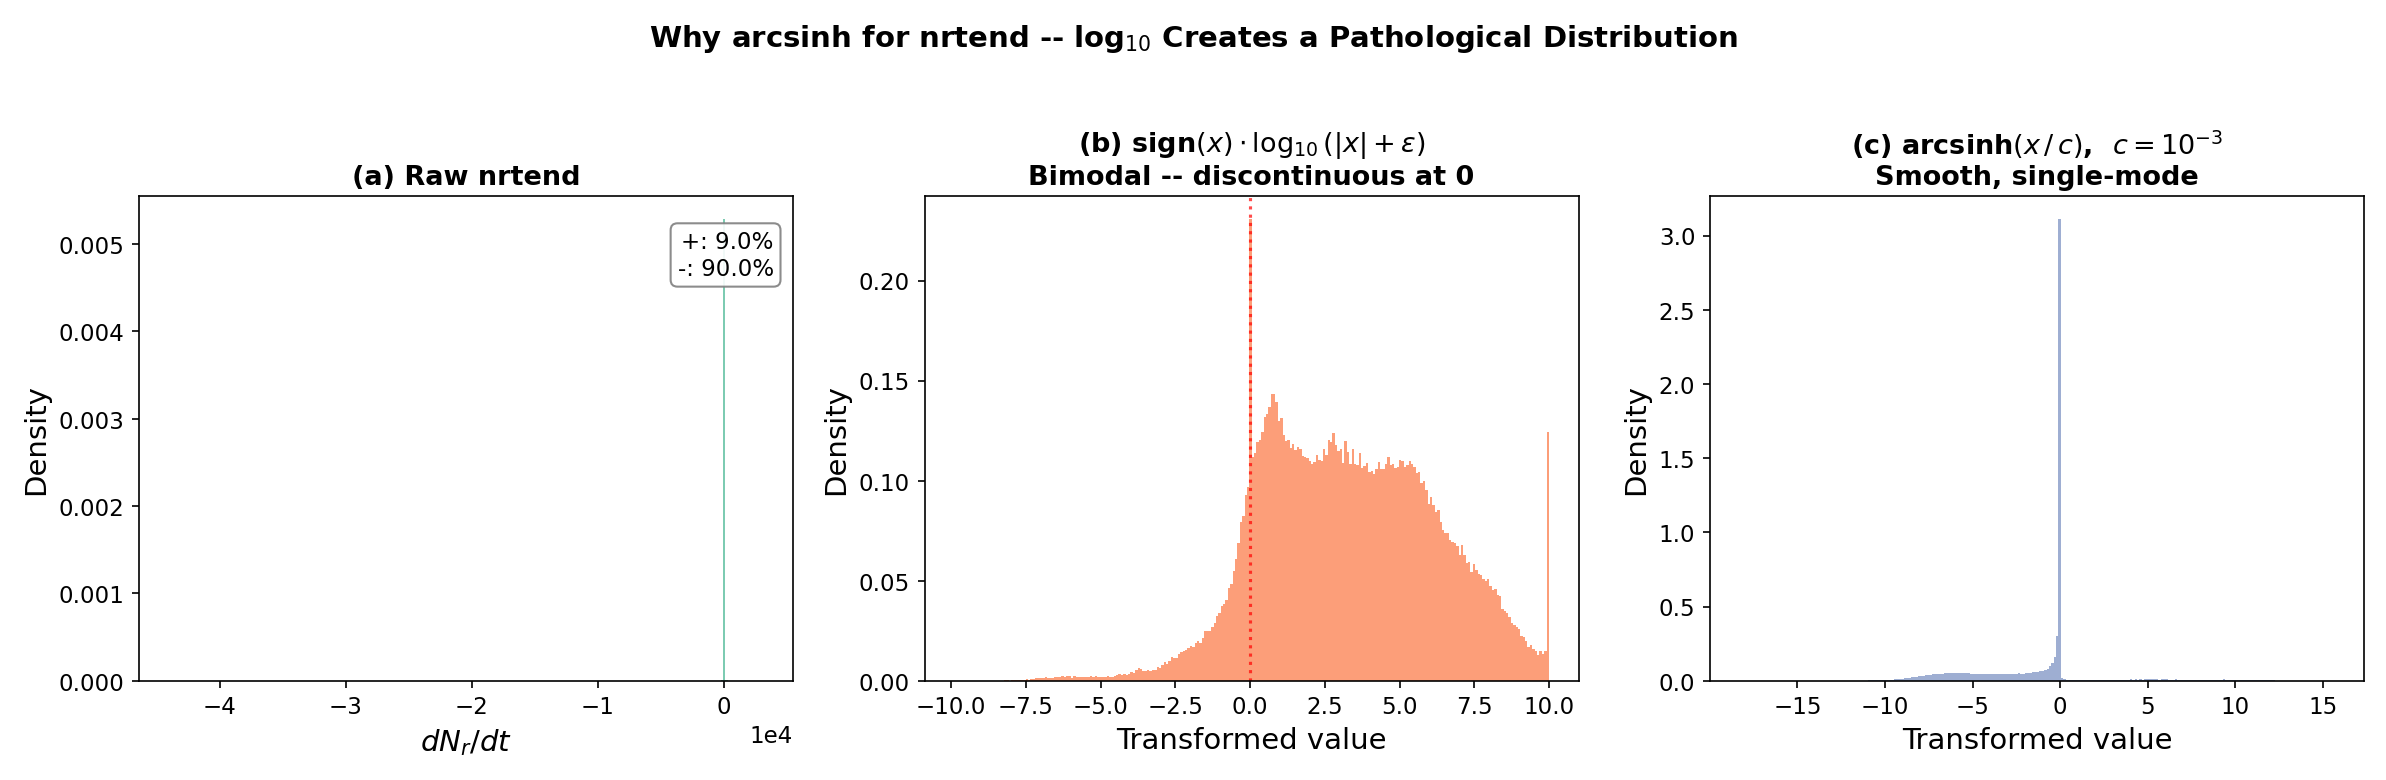

In [9]:
active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
nrtend = data.loc[active_mask, 'nrtend_TAU'].dropna().values

eps = 1e-10
c = 1e-3  # arcsinh threshold from config

raw = nrtend
sign_log = np.sign(nrtend) * np.log10(np.abs(nrtend) + eps)
asinh = np.arcsinh(nrtend / c)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Panel A: Raw
axes[0].hist(raw, bins=250, color='#66c2a5', edgecolor='none', alpha=0.85, density=True)
pos_pct = np.mean(raw > 0) * 100
neg_pct = np.mean(raw < 0) * 100
axes[0].set_title('(a) Raw nrtend', fontsize=13, fontweight='bold')
axes[0].set_xlabel(r'$dN_r/dt$')
axes[0].set_ylabel('Density')
axes[0].text(0.97, 0.93, f'+: {pos_pct:.1f}%\n-: {neg_pct:.1f}%',
             transform=axes[0].transAxes, ha='right', va='top', fontsize=11,
             bbox=dict(boxstyle='round', fc='white', ec='gray', alpha=0.9))
axes[0].ticklabel_format(axis='x', style='scientific', scilimits=(-3, 3))

# Panel B: Sign-preserving log10
axes[1].hist(sign_log, bins=250, color='#fc8d62', edgecolor='none', alpha=0.85, density=True)
axes[1].set_title(r'(b) sign$(x)\cdot\log_{10}(|x|+\epsilon)$' + '\nBimodal -- discontinuous at 0',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('Transformed value')
axes[1].set_ylabel('Density')
axes[1].axvline(0, color='red', linestyle=':', linewidth=1.5, alpha=0.7)

# Panel C: arcsinh
axes[2].hist(asinh, bins=250, color='#8da0cb', edgecolor='none', alpha=0.85, density=True)
axes[2].set_title(r'(c) arcsinh$(x\,/\,c)$,  $c=10^{-3}$' + '\nSmooth, single-mode',
                  fontsize=13, fontweight='bold')
axes[2].set_xlabel('Transformed value')
axes[2].set_ylabel('Density')

fig.suptitle('Why arcsinh for nrtend -- log$_{10}$ Creates a Pathological Distribution',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig7_arcsinh_nrtend.png')
plt.show()

---
## MoE Justification: nrtend Regime Heterogeneity
**Saved figures:** `figures/fig8_moe_regimes.png` (log inputs, raw $dN_r/dt$), `figures/fig8b_moe_raw_inputs.png` (raw inputs and raw $dN_r/dt$), `figures/fig8c_moe_log_log.png` (log inputs vs sign–log $dN_r/dt$).

**Design choice:** Replace the single nrtend regression head with a
Mixture-of-Experts (MoE) module containing 3 expert networks and a learned
router, where each expert specializes in one physical regime of nrtend.

**Data-driven argument:** The rain droplet number tendency exhibits three
qualitatively distinct physical regimes -- near-zero (negligible change),
negative (self-collection dominates), and positive (rain formation via
autoconversion/accretion).  The input-output relationship differs substantially
across these regimes.  A single head must implicitly learn to switch behavior;
an explicit MoE with a router can specialize each expert and route accordingly.

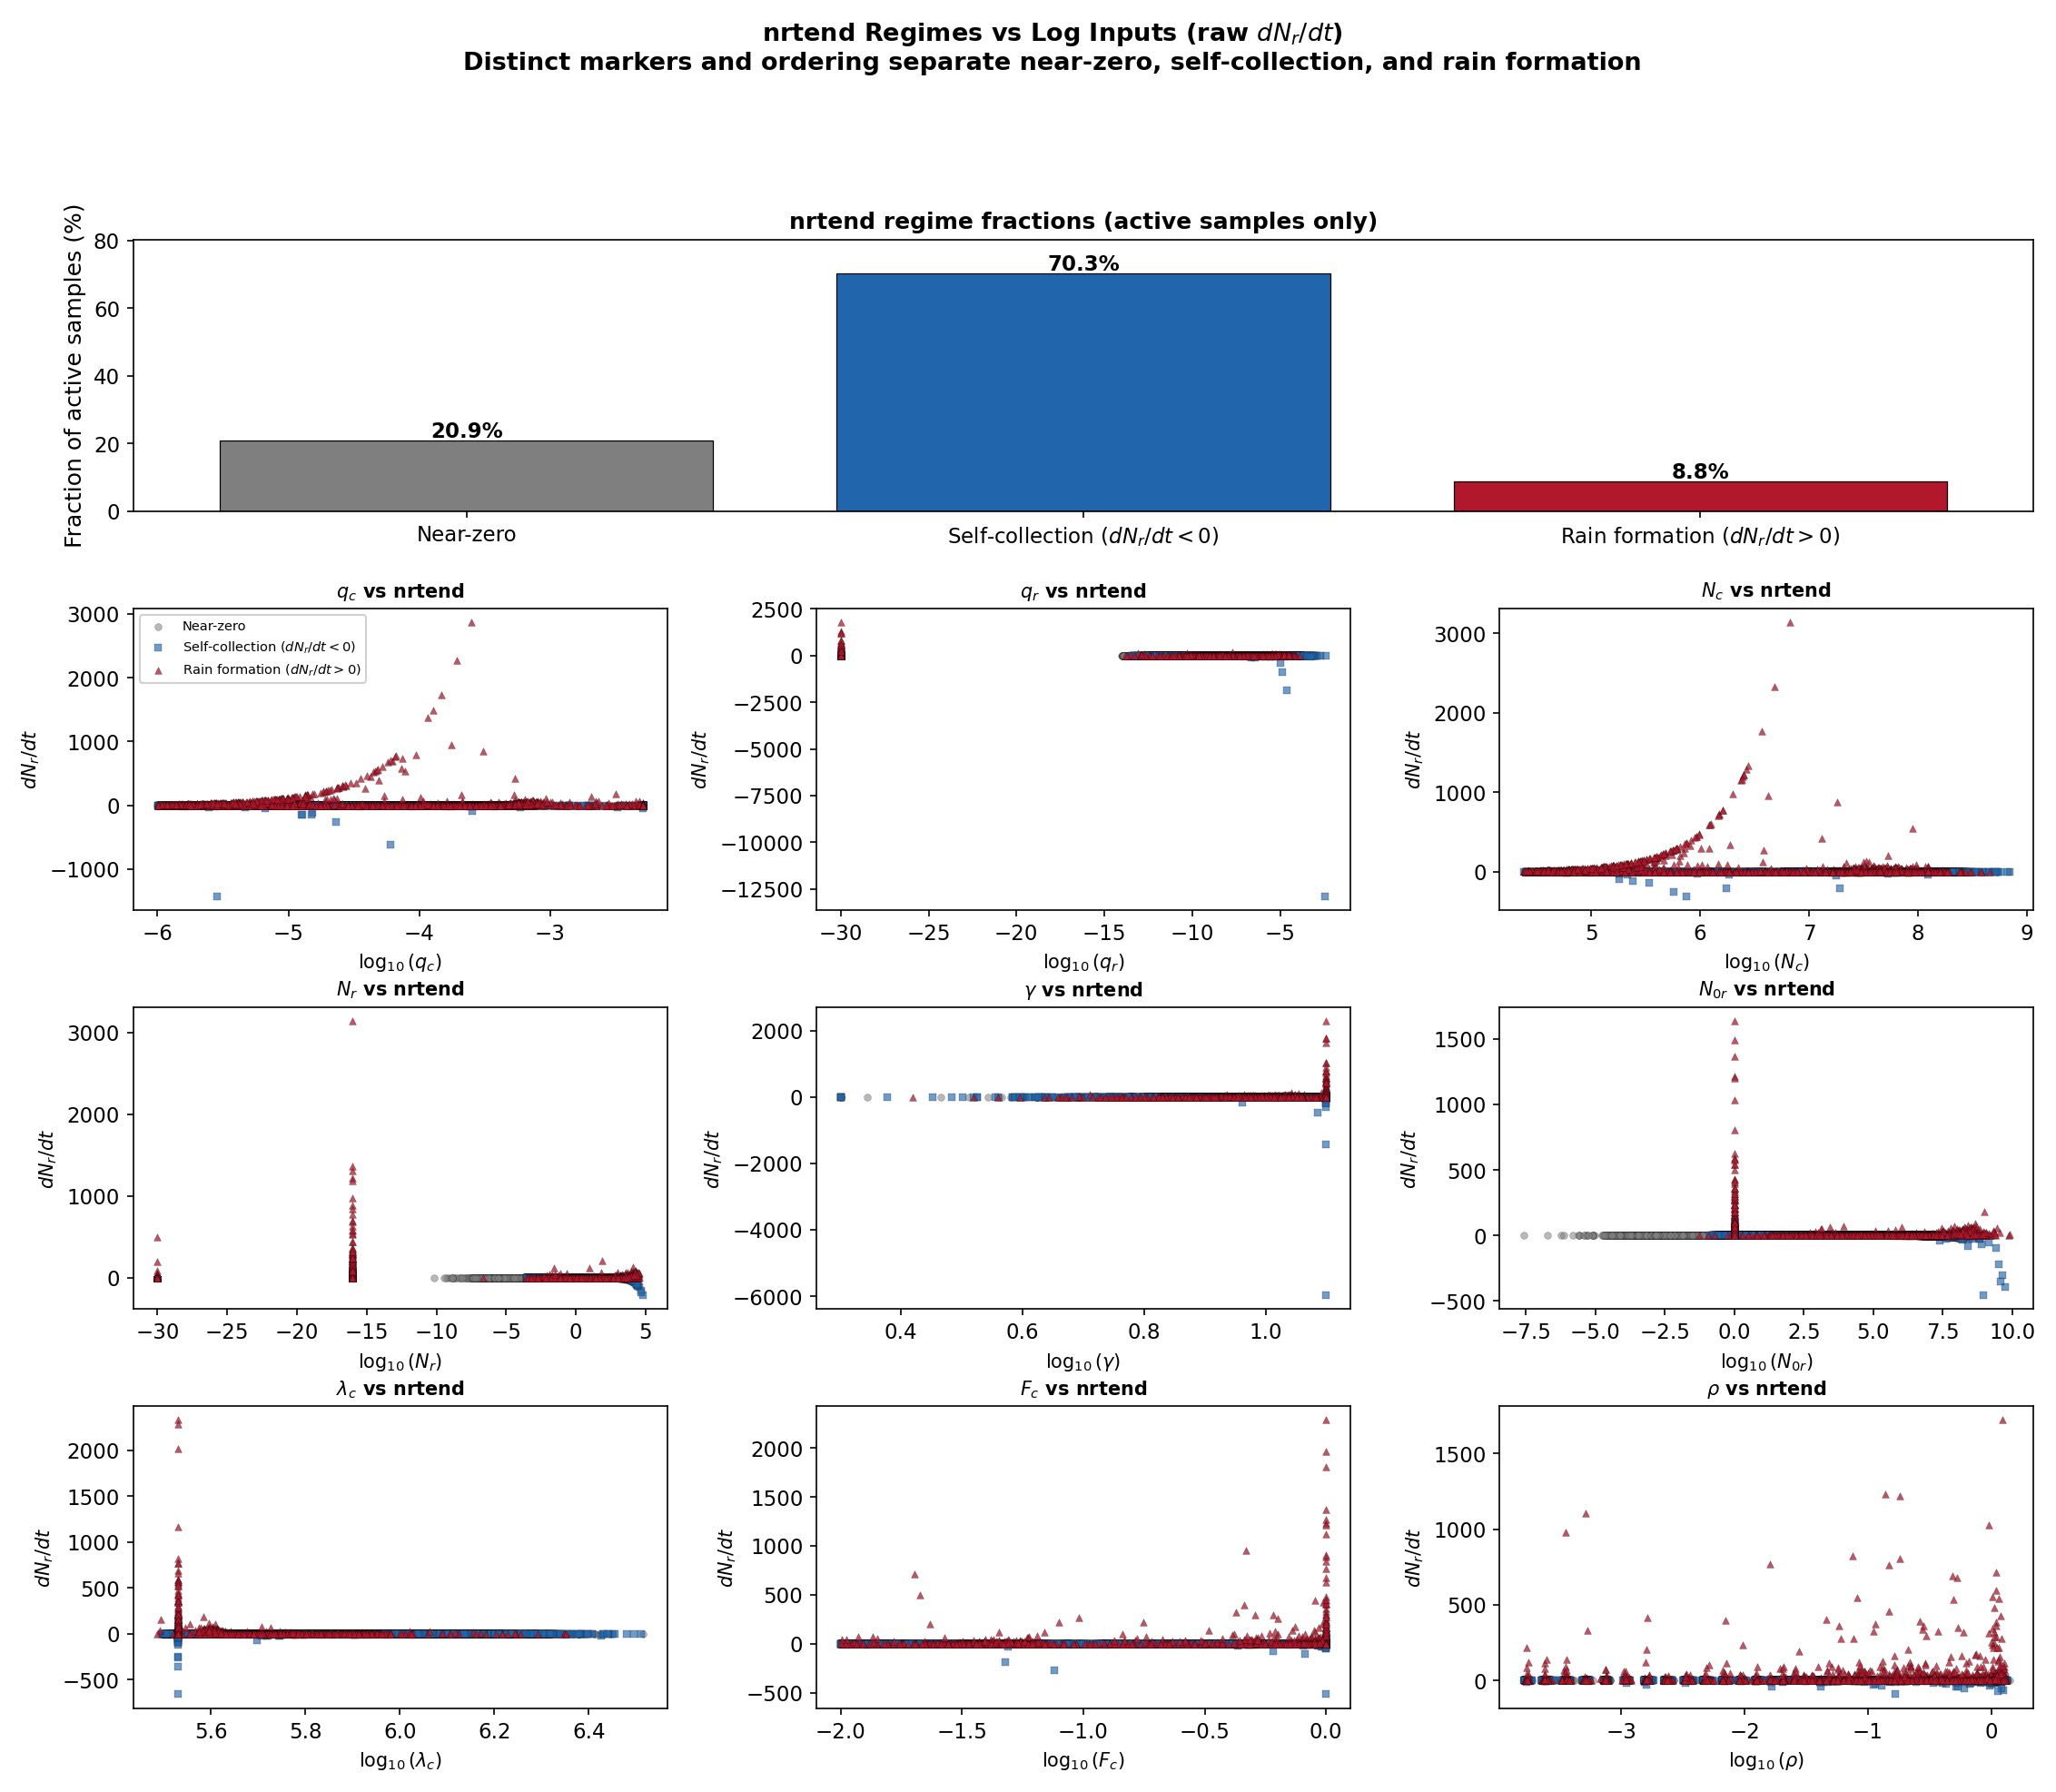

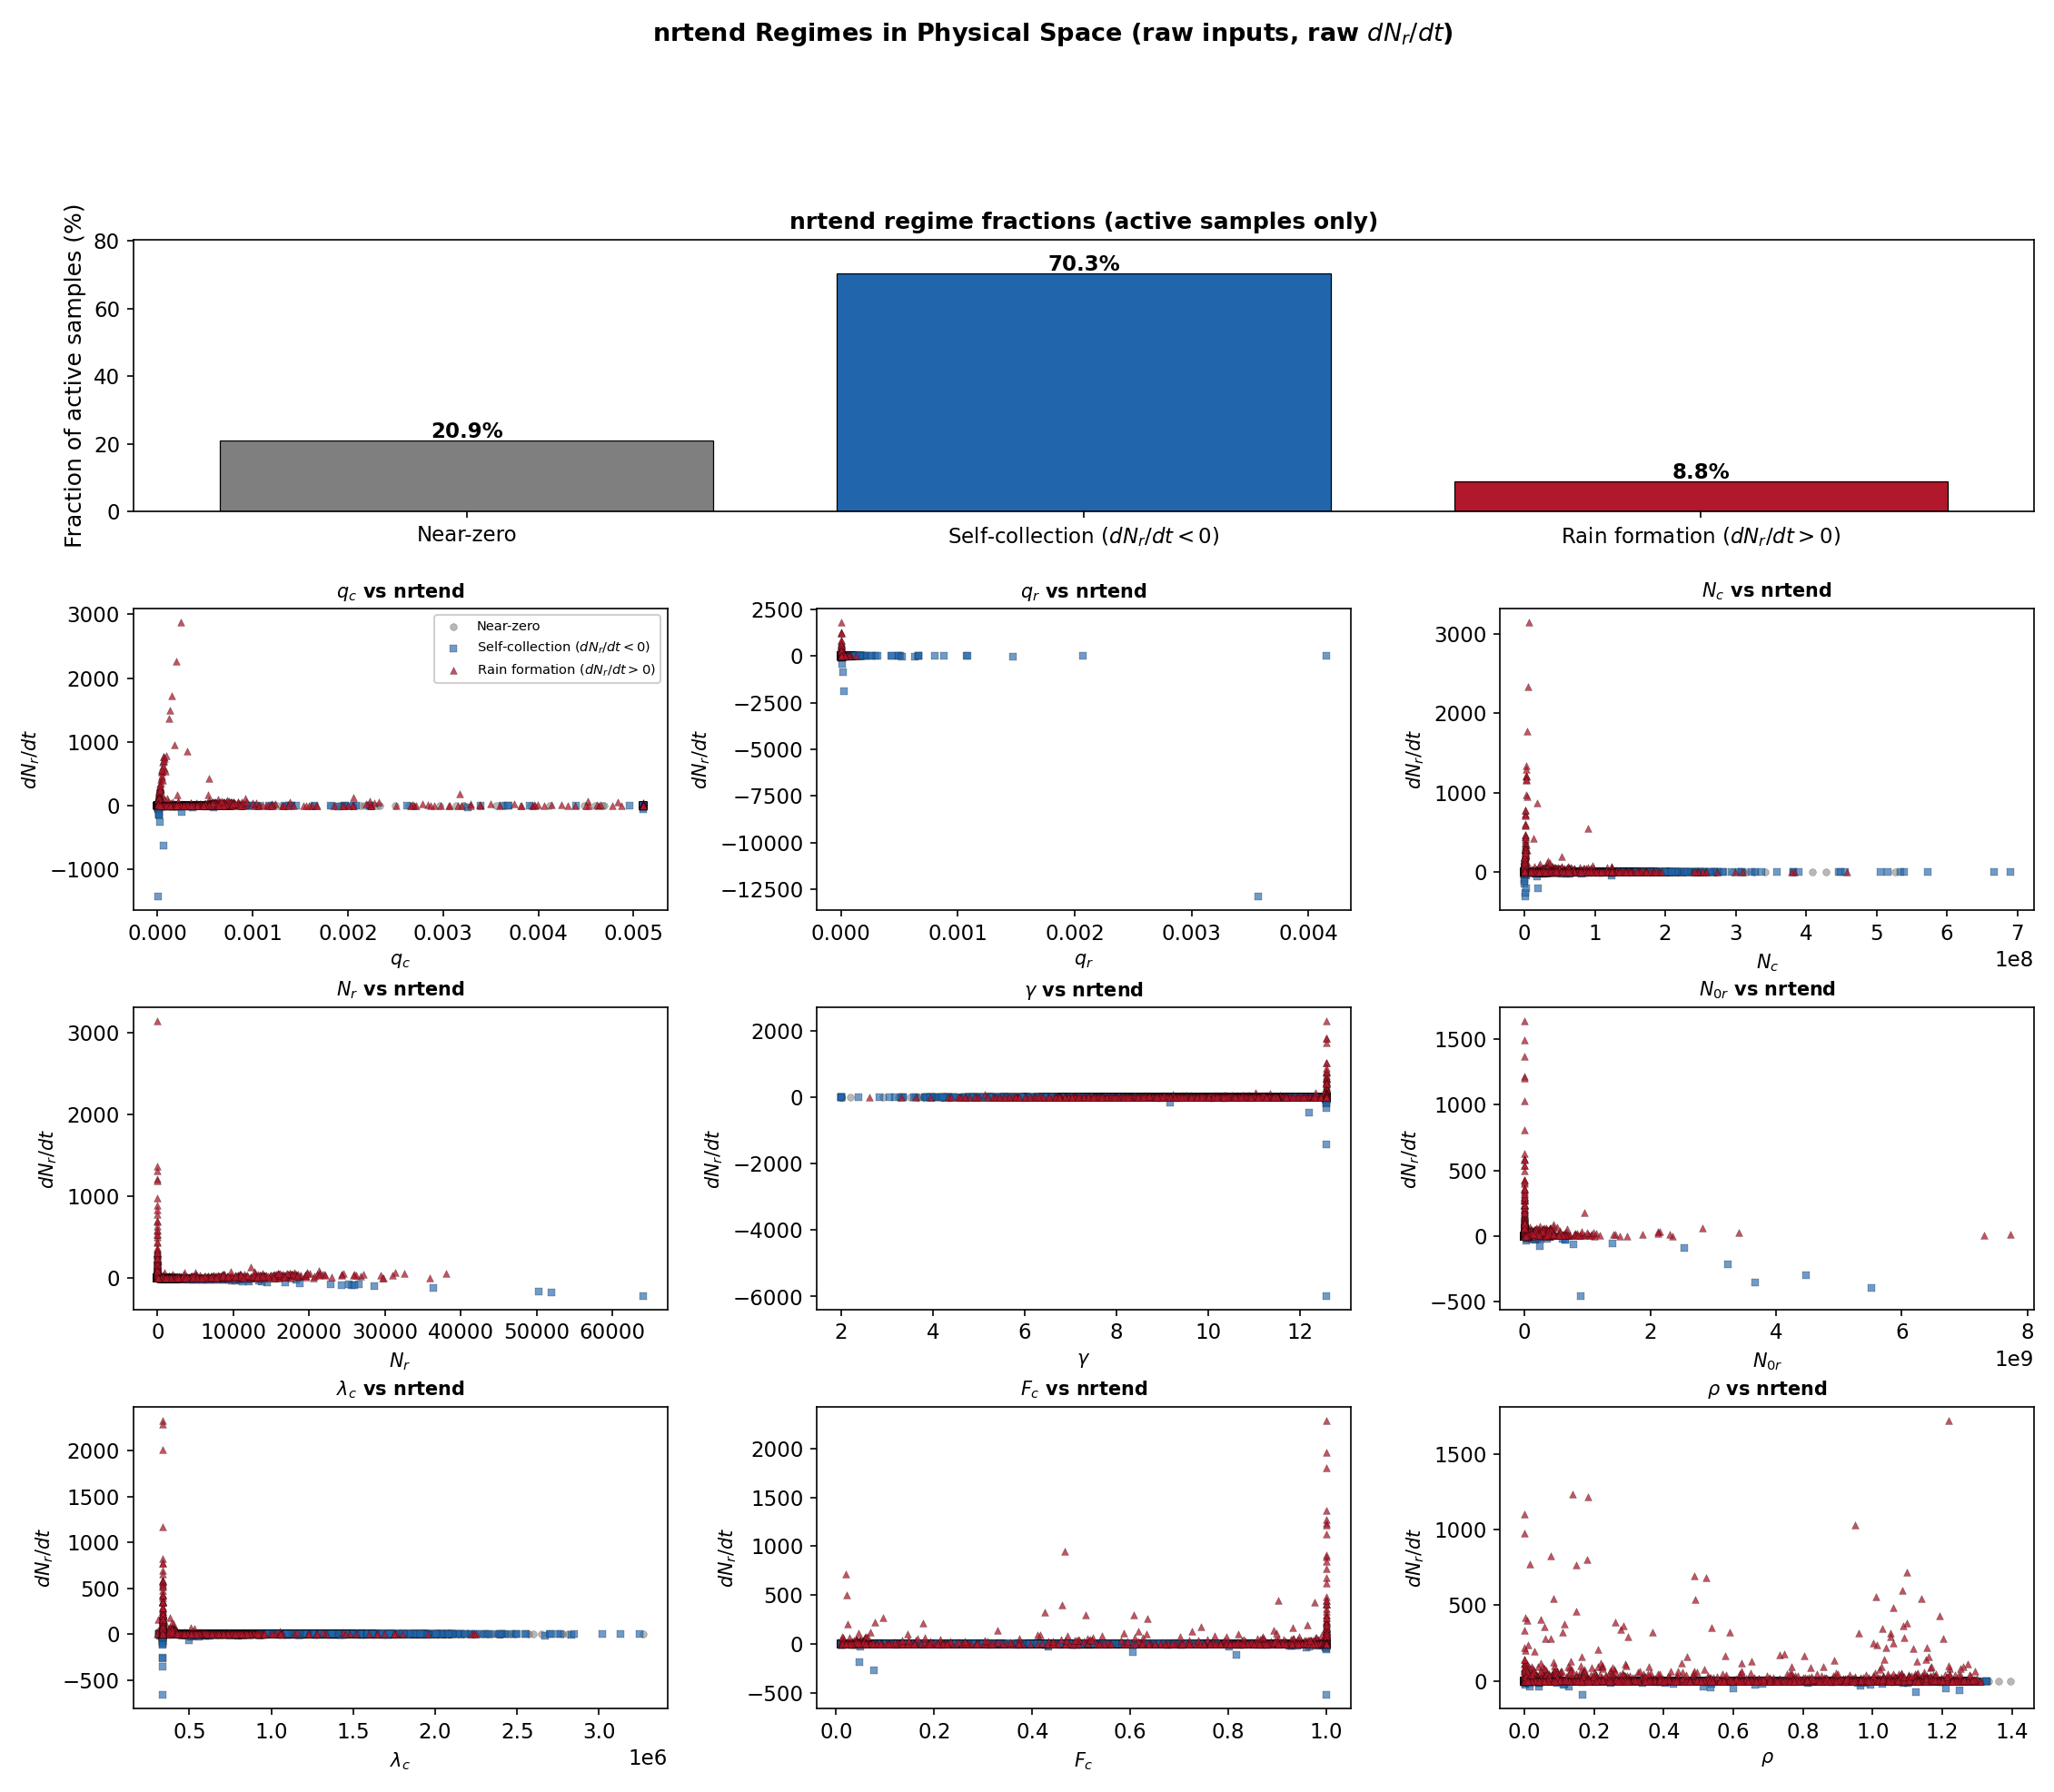

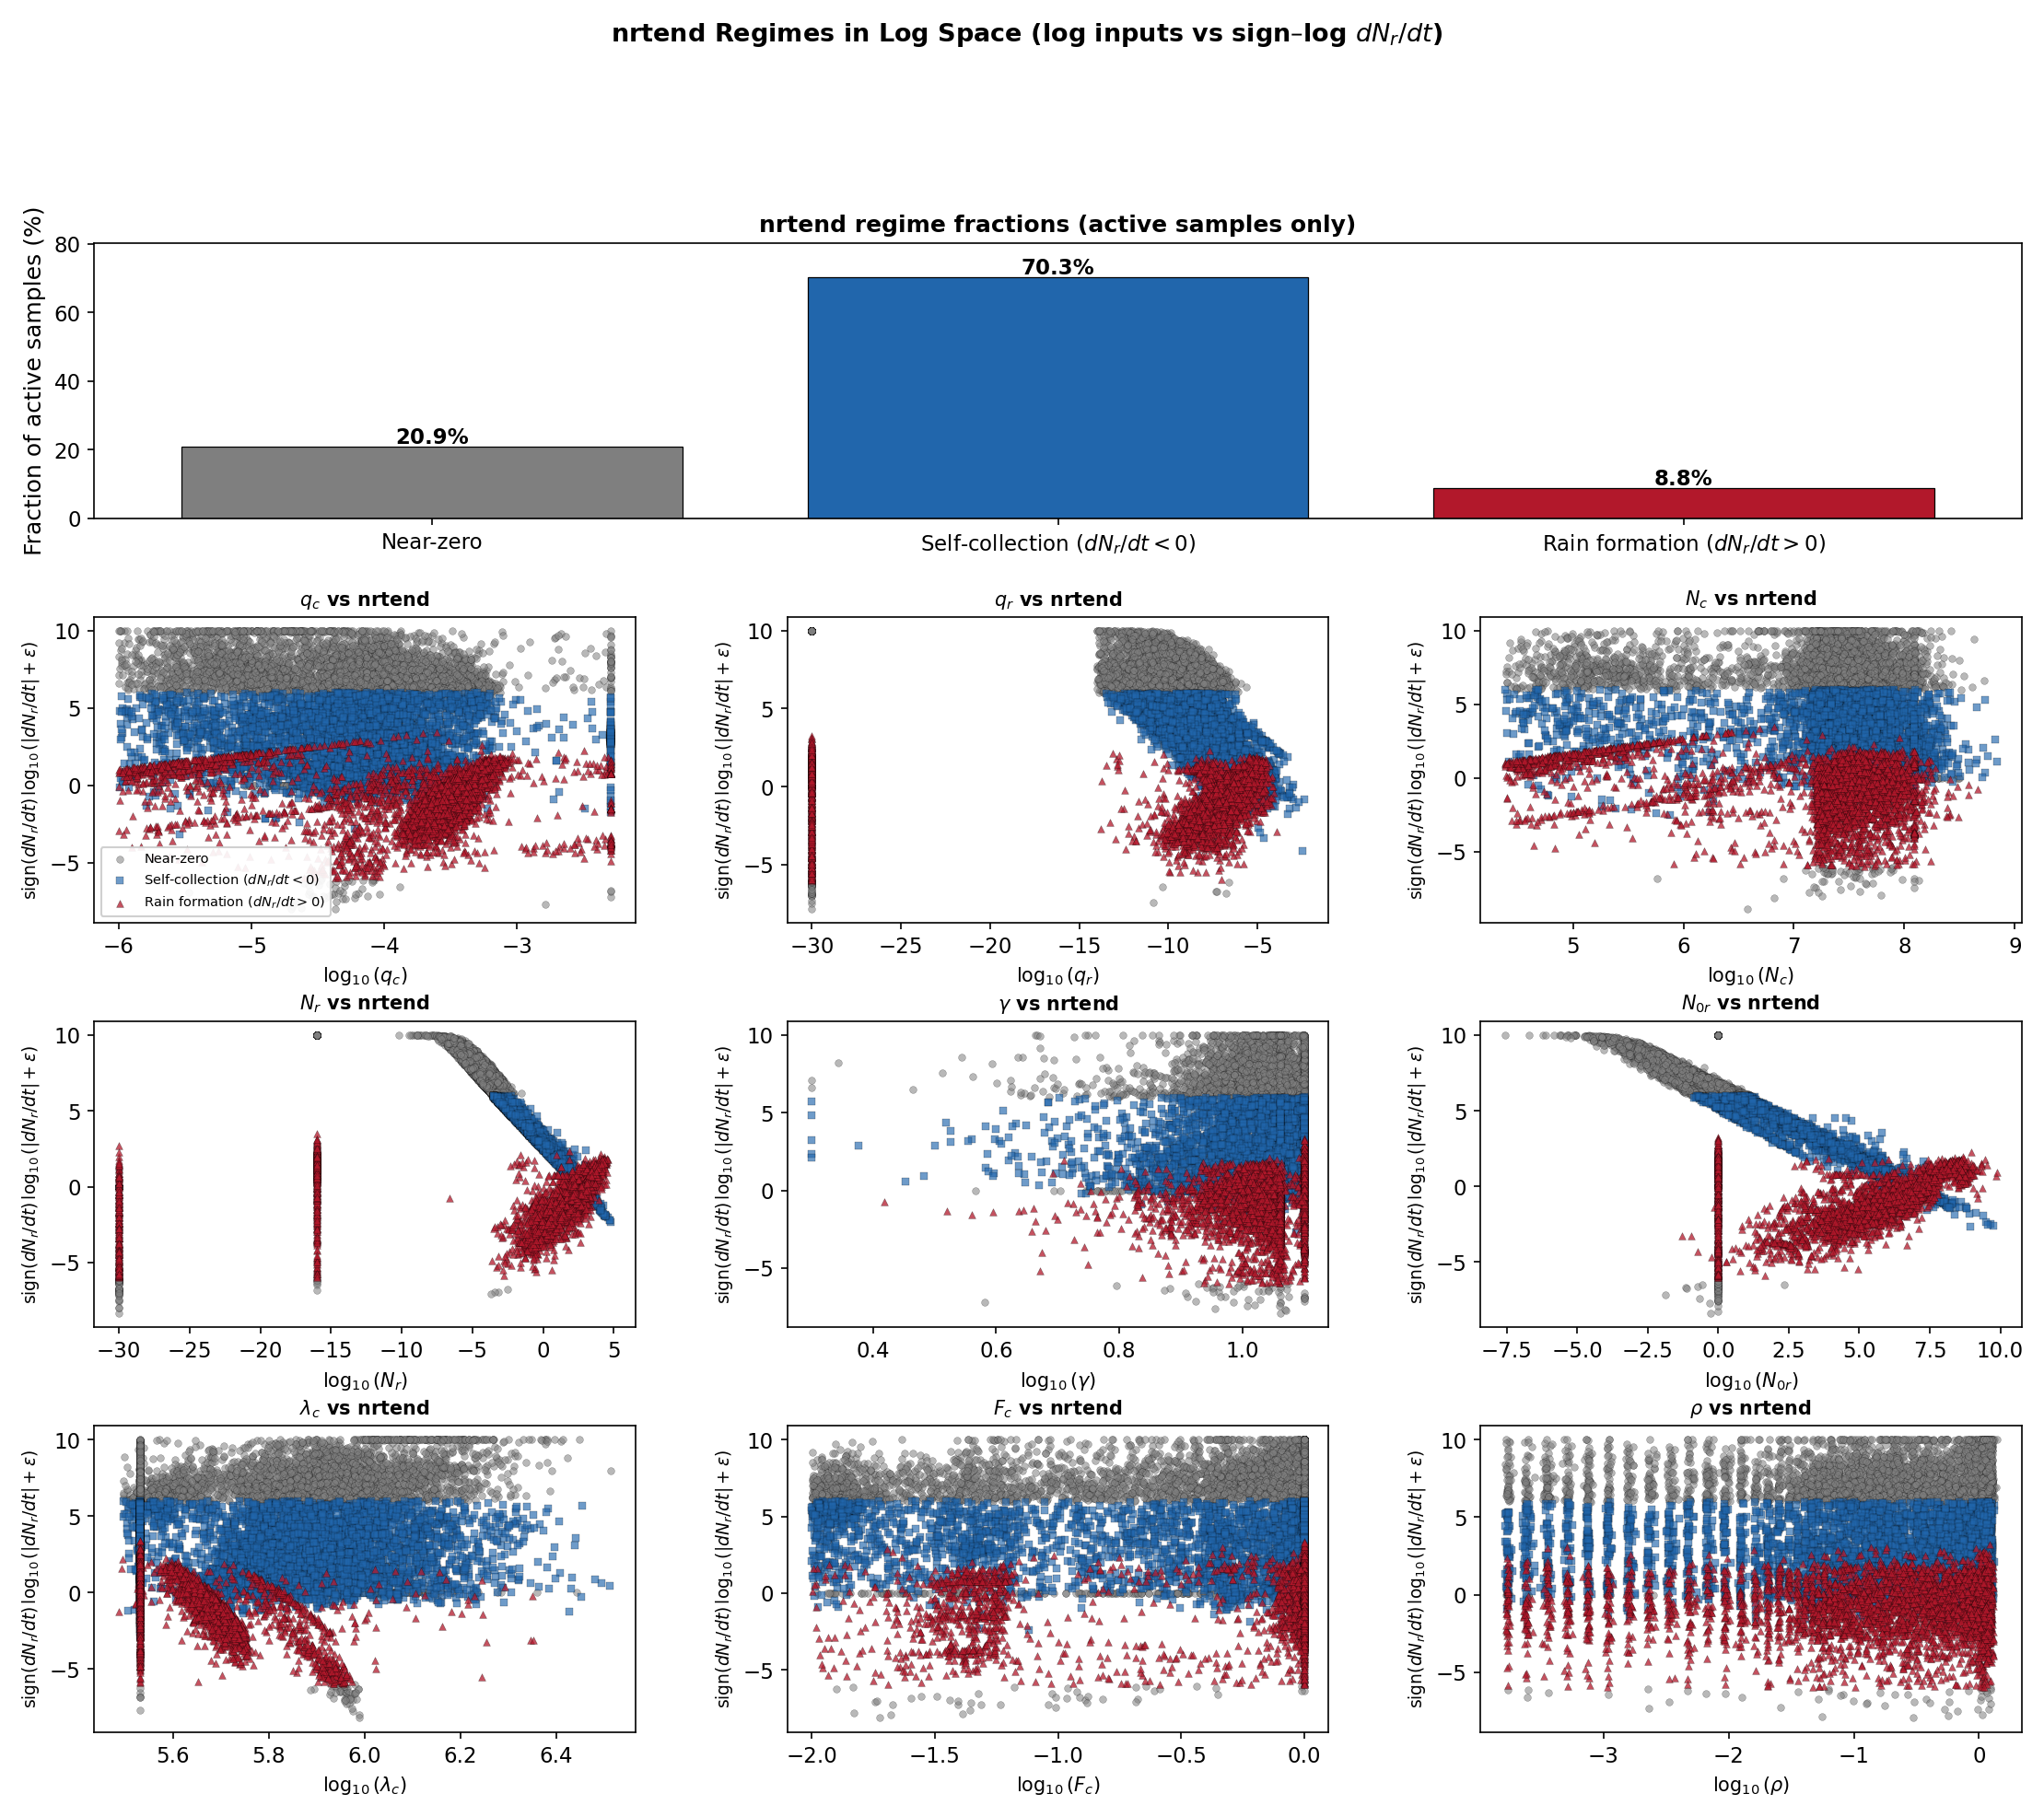

In [10]:
from matplotlib import gridspec

active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
active_full = data.loc[active_mask].copy()

threshold = 1e-6
nrtend = active_full['nrtend_TAU'].values
regime = np.where(
    np.abs(nrtend) < threshold,
    'near_zero',
    np.where(nrtend < -threshold, 'negative', 'positive'),
)
active_full['regime'] = regime

REGIME_STYLE = {
    'near_zero': {'color': '#7f7f7f', 'marker': 'o', 'label': 'Near-zero', 'zorder': 2, 'alpha': 0.55},
    'negative': {'color': '#2166ac', 'marker': 's', 'label': 'Self-collection ($dN_r/dt<0$)', 'zorder': 3, 'alpha': 0.65},
    'positive': {'color': '#b2182b', 'marker': '^', 'label': 'Rain formation ($dN_r/dt>0$)', 'zorder': 4, 'alpha': 0.75},
}

INPUT_PANELS = [
    ('QC_TAU_in', r'$q_c$', r'$\log_{10}(q_c)$'),
    ('QR_TAU_in', r'$q_r$', r'$\log_{10}(q_r)$'),
    ('NC_TAU_in', r'$N_c$', r'$\log_{10}(N_c)$'),
    ('NR_TAU_in', r'$N_r$', r'$\log_{10}(N_r)$'),
    ('PGAM', r'$\gamma$', r'$\log_{10}(\gamma)$'),
    ('N0R', r'$N_{0r}$', r'$\log_{10}(N_{0r})$'),
    ('LAMC', r'$\lambda_c$', r'$\log_{10}(\lambda_c)$'),
    ('CLOUD', r'$F_c$', r'$\log_{10}(F_c)$'),
    ('RHO_CLUBB', r'$\rho$', r'$\log_{10}(\rho)$'),
]

EPS_LOG = 1e-10
EPS_X = 1e-30


def sign_log10_y(y):
    return np.sign(y) * np.log10(np.abs(y) + EPS_LOG)


def plot_moe_figure(mode, fname, suptitle):
    """
    mode: 'log_phys'  -> log10(input) vs raw nrtend
          'raw_raw'   -> raw input vs raw nrtend
          'log_log'   -> log10(input) vs sign*log10(|nrtend|)
    """
    np.random.seed(42)
    n_per = 4000
    fig = plt.figure(figsize=(18, 14))
    gs = gridspec.GridSpec(4, 3, figure=fig, height_ratios=[0.9, 1, 1, 1], hspace=0.33, wspace=0.28)
    ax_bar = fig.add_subplot(gs[0, :])
    counts = active_full['regime'].value_counts()
    order = ['near_zero', 'negative', 'positive']
    pct = [counts.get(k, 0) / len(active_full) * 100 for k in order]
    bars = ax_bar.bar(
        [REGIME_STYLE[k]['label'] for k in order],
        pct,
        color=[REGIME_STYLE[k]['color'] for k in order],
        edgecolor='black',
        linewidth=0.6,
    )
    for b, p in zip(bars, pct):
        ax_bar.text(b.get_x() + b.get_width() / 2, b.get_height() + 0.8, f'{p:.1f}%',
                    ha='center', fontsize=11, fontweight='bold')
    ax_bar.set_ylabel('Fraction of active samples (%)', fontsize=12)
    ax_bar.set_title('nrtend regime fractions (active samples only)', fontsize=12, fontweight='bold')
    ax_bar.set_ylim(0, max(pct) + 10)

    for i, (in_col, xlab_phys, xlab_log) in enumerate(INPUT_PANELS):
        r, c = 1 + i // 3, i % 3
        ax = fig.add_subplot(gs[r, c])
        for reg in order:
            sub = active_full.loc[active_full['regime'] == reg]
            if len(sub) == 0:
                continue
            if len(sub) > n_per:
                sub = sub.sample(n=n_per, random_state=42 + i)
            x = sub[in_col].values.astype(np.float64)
            y = sub['nrtend_TAU'].values.astype(np.float64)
            st = REGIME_STYLE[reg]
            if mode == 'raw_raw':
                xv, yv = x, y
                ax.set_xlabel(xlab_phys, fontsize=10)
                ax.set_ylabel(r'$dN_r/dt$', fontsize=10)
            elif mode == 'log_phys':
                xv = np.log10(np.maximum(x, EPS_X))
                yv = y
                ax.set_xlabel(xlab_log, fontsize=10)
                ax.set_ylabel(r'$dN_r/dt$', fontsize=10)
            else:  # log_log
                xv = np.log10(np.maximum(x, EPS_X))
                yv = sign_log10_y(y)
                ax.set_xlabel(xlab_log, fontsize=10)
                ax.set_ylabel(r'$\mathrm{sign}(dN_r/dt)\,\log_{10}(|dN_r/dt|+\epsilon)$', fontsize=9)
            lbl = st['label'] if i == 0 else None
            ax.scatter(
                xv, yv, s=14, alpha=st['alpha'], c=st['color'], marker=st['marker'],
                edgecolors='k', linewidths=0.15, label=lbl, zorder=st['zorder'], rasterized=True,
            )
        ax.set_title(f'{xlab_phys} vs nrtend', fontsize=10, fontweight='bold')
        if i == 0:
            ax.legend(fontsize=7, loc='best', framealpha=0.92)
    fig.suptitle(suptitle, fontsize=13, fontweight='bold', y=0.995)
    plt.savefig(FIG_DIR / fname)
    plt.show()


plot_moe_figure(
    'log_phys', 'fig8_moe_regimes.png',
    'nrtend Regimes vs Log Inputs (raw $dN_r/dt$)\n'
    'Distinct markers and ordering separate near-zero, self-collection, and rain formation',
)
plot_moe_figure(
    'raw_raw', 'fig8b_moe_raw_inputs.png',
    'nrtend Regimes in Physical Space (raw inputs, raw $dN_r/dt$)',
)
plot_moe_figure(
    'log_log', 'fig8c_moe_log_log.png',
    'nrtend Regimes in Log Space (log inputs vs sign–log $dN_r/dt$)',
)


---
## Input Filtering Thresholds and Huber Loss

**Design choices:**
1. **Input filtering:** Discard samples where QC\_TAU\_in $\leq 10^{-6}$ or
   cloud fraction $\leq$ 0.01 before training.
2. **Huber loss:** Use Huber loss ($\delta=1$) instead of MSE for regression.

**Data-driven arguments:**
- Below the QC\_TAU and cloud-fraction thresholds, output tendencies collapse to
  machine-epsilon noise -- there is no physical signal to learn from.  Including
  these samples wastes capacity and biases the model toward predicting zeros.
- Even after log-transform, the tendency distributions have heavy tails (extreme
  outliers).  MSE loss would be dominated by these tail points; Huber loss
  transitions to a linear penalty beyond $\delta$, providing robustness.

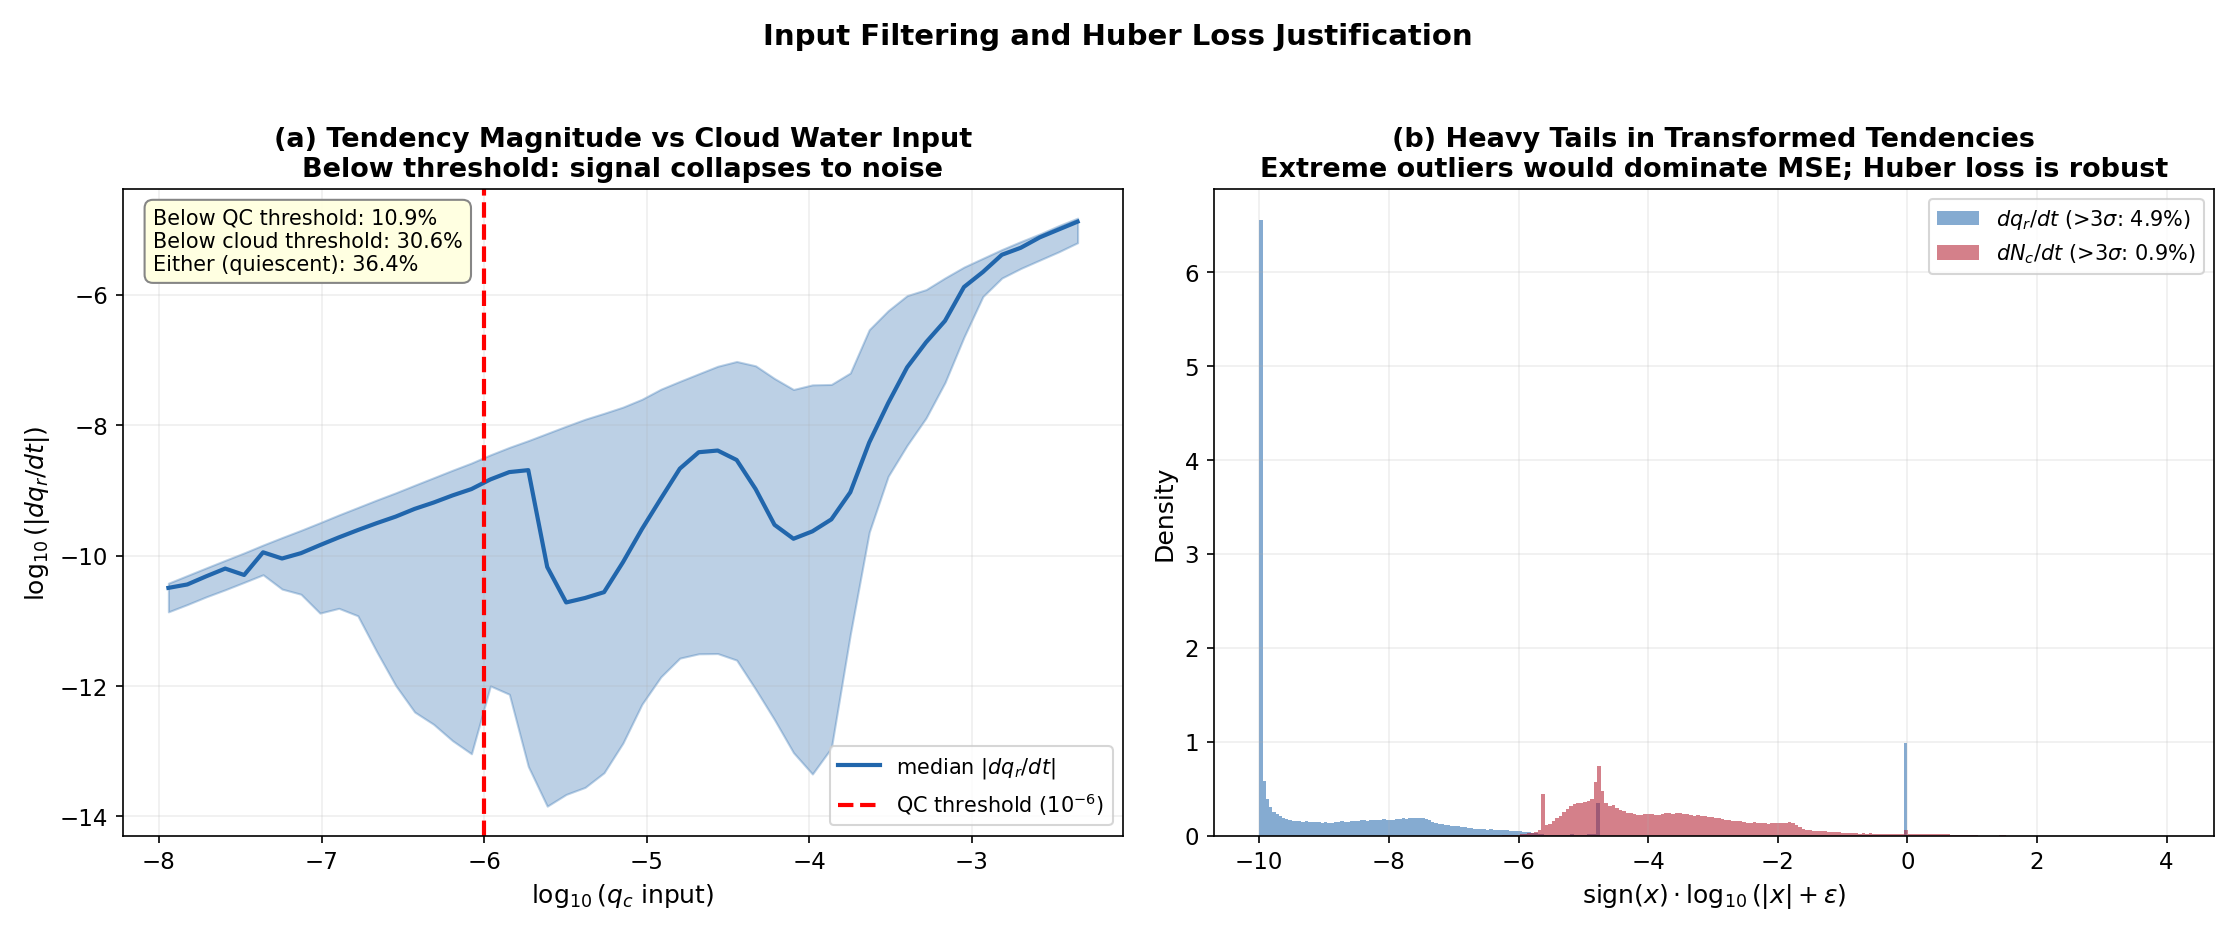

In [11]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# --- Panel A: Tendency magnitude vs QC_TAU_in (log-log binned) ---
qc = data['QC_TAU_in'].values
tend_mag = np.abs(data['qrtend_TAU'].values)

# Bin QC_TAU_in in log space
qc_pos = qc[qc > 0]
tend_pos = tend_mag[qc > 0]
log_bins = np.linspace(np.log10(qc_pos.min() + 1e-30), np.log10(qc_pos.max()), 50)
bin_centers = []
bin_medians = []
bin_p25 = []
bin_p75 = []

for i in range(len(log_bins) - 1):
    mask = (np.log10(qc_pos + 1e-30) >= log_bins[i]) & (np.log10(qc_pos + 1e-30) < log_bins[i+1])
    if mask.sum() > 10:
        bin_centers.append((log_bins[i] + log_bins[i+1]) / 2)
        vals = tend_pos[mask]
        bin_medians.append(np.median(vals))
        bin_p25.append(np.percentile(vals, 25))
        bin_p75.append(np.percentile(vals, 75))

bin_centers = np.array(bin_centers)
bin_medians = np.array(bin_medians)
bin_p25 = np.array(bin_p25)
bin_p75 = np.array(bin_p75)

ax1.fill_between(bin_centers, np.log10(bin_p25 + 1e-30), np.log10(bin_p75 + 1e-30),
                 alpha=0.3, color=COLORS['qrtend'])
ax1.plot(bin_centers, np.log10(bin_medians + 1e-30), '-', color=COLORS['qrtend'],
         linewidth=2, label=r'median $|dq_r/dt|$')
ax1.axvline(np.log10(1e-6), color='red', linestyle='--', linewidth=2,
            label=r'QC threshold ($10^{-6}$)')

# Annotate fractions
below = np.mean(qc <= 1e-6) * 100
below_cloud = np.mean(data['CLOUD'] <= 0.01) * 100
either = np.mean((qc <= 1e-6) | (data['CLOUD'].values <= 0.01)) * 100
ax1.text(0.03, 0.97,
         f'Below QC threshold: {below:.1f}%\n'
         f'Below cloud threshold: {below_cloud:.1f}%\n'
         f'Either (quiescent): {either:.1f}%',
         transform=ax1.transAxes, va='top', fontsize=10,
         bbox=dict(boxstyle='round,pad=0.4', fc='lightyellow', ec='gray', alpha=0.95))

ax1.set_xlabel(r'$\log_{10}$($q_c$ input)', fontsize=12)
ax1.set_ylabel(r'$\log_{10}$(|$dq_r/dt$|)', fontsize=12)
ax1.set_title('(a) Tendency Magnitude vs Cloud Water Input\n'
              'Below threshold: signal collapses to noise',
              fontsize=13, fontweight='bold')
ax1.legend(fontsize=10, loc='lower right')
ax1.grid(True, alpha=0.2)

# --- Panel B: Heavy tails of log-transformed tendencies ---
active_mask = (data['QC_TAU_in'] > 1e-6) & (data['CLOUD'] > 0.01)
active = data.loc[active_mask]

eps = 1e-10
for col, color, label in [
    ('qrtend_TAU', COLORS['qrtend'], OUTPUT_LABELS_SHORT['qrtend_TAU']),
    ('nctend_TAU', COLORS['nctend'], OUTPUT_LABELS_SHORT['nctend_TAU']),
]:
    vals = active[col].dropna().values
    log_vals = np.sign(vals) * np.log10(np.abs(vals) + eps)
    mu, sigma = np.mean(log_vals), np.std(log_vals)
    tail_frac = np.mean(np.abs(log_vals - mu) > 3 * sigma) * 100
    ax2.hist(log_vals, bins=200, color=color, alpha=0.55, density=True,
             edgecolor='none', label=f'{label} (>{3}$\\sigma$: {tail_frac:.1f}%)')

ax2.set_xlabel('sign$(x) \\cdot \\log_{10}(|x| + \\epsilon)$', fontsize=12)
ax2.set_ylabel('Density', fontsize=12)
ax2.set_title('(b) Heavy Tails in Transformed Tendencies\n'
              'Extreme outliers would dominate MSE; Huber loss is robust',
              fontsize=13, fontweight='bold')
ax2.legend(fontsize=10, frameon=True)
ax2.grid(True, alpha=0.2)

fig.suptitle('Input Filtering and Huber Loss Justification',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig(FIG_DIR / 'fig9_filtering_huber.png')
plt.show()